(phillips_drifts_volatilities)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img
                    style="width:250px;display:inline;"
                    width="250px"
                    src="https://assets.quantecon.org/img/qe-menubar-logo.svg"
                    alt="QuantEcon"
                >
        </a>
</div>
```

# 漂移与波动率

```{index} single: Phillips Curve; Drifts and Volatilities
```

```{contents} Contents
:depth: 2
```

## 概览

本节的讲座讲述了一个关于政府对菲利普斯曲线的*模型*、以及由此引发的*政策*如何随时间*漂移*的故事。

在 {doc}`phillips_learning` 和 {doc}`phillips_escaping_nash` 中，一个不断拟合并重新拟合近似菲利普斯曲线的政府，沿着一条*逃逸路径*被反复推离一个糟糕的 {doc}`自我实现均衡 <phillips_self_confirming>`；而 {doc}`phillips_priors` 和 {doc}`phillips_lost_conquest` 则用漂移的信念来解释美国通货膨胀的起落。

那些讲座主要讲的是*理论*。

本讲座转向*数据*。

它研究了 {cite:t}`CogleySargent2005` 一文，该文提出了一个看似简单的问题：

> 当我们审视美国战后关于通货膨胀、失业和利率的时间序列时，是否能看到动态发生了*漂移*的证据？

蒂姆·科格利（Tim Cogley）和托马斯·萨金特开始这项工作，是作为《征服》一书 {cite}`Sargent1999` 和逃逸路径论文 {cite}`ChoWilliamsSargent2002` 的实证配套研究。

这也是对 {cite:t}`Sims2001comment` 和 {cite:t}`Stock2001comment` 对早期论文 {cite}`CogleySargent2001` 所作的深入评论的回应，并演变成与 {cite:t}`SimsZha2006` 和 {cite:t}`BernankeMihov1998` 之间的一场友好辩论，辩论的主题正是贯穿本节的核心问题：

*20世纪70年代的大通胀及其在80年代的平息，究竟是政策不当的故事，还是运气不好的故事？*

要让数据回答这个问题，我们需要一个足够灵活、能同时容纳*两种*答案的统计模型。

这个模型是一个*贝叶斯向量自回归模型，其系数按随机游走漂移，其冲击方差按随机波动率演化*。

拟合它需要一种马尔可夫链蒙特卡洛算法，该算法结合了 {doc}`卡尔曼滤波 <kalman>`、{cite:t}`CarterKohn1994` 的前向滤波/后向抽样平滑器，以及 {cite:t}`Jacquier1994` 的随机波动率抽样器。

希望了解背景知识的读者可以在 {doc}`var_dmd` 中找到伴随形式的向量自回归，在 {doc}`kalman_2` 中找到卡尔曼平滑器，在 {doc}`ar1_bayes` 和 {doc}`ar1_turningpts` 中找到通过 MCMC 对状态空间模型进行的贝叶斯推断。

我们将依次讲解数据变换、先验、抽样器和主要的实证结果。

让我们从一些导入语句和数据的 URL 开始。

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Math
from scipy import linalg
from scipy.special import expit
from scipy.stats import invwishart


data_url = 'https://github.com/QuantEcon/data-lectures/raw/main/lectures/NEWQDATA.csv'

## 政策不当还是运气不好？

有两种颇为可信的观点相互竞争，用以解释美国的大通胀——这与 {doc}`phillips_two_stories` 开篇提出的“胜利”与“昭雪”这两种故事是同一对立面。

**政策不当**的观点是本节乃至《征服》一书 {cite}`Sargent1999` 中反复演绎的观点。

亚瑟·伯恩斯（Arthur Burns）对经济的某种*模型*、他的*耐心*，或他无法*承诺*一条更好的规则，导致美联储以一种造成美国和平时期历史上最严重通胀的方式来实施货币政策；而一个改进的模型、更多的耐心，或更强的纪律性，则使保罗·沃尔克（Paul Volcker）得以将其平息 {cite}`DeLong1997,Taylor1997comment`。

按照这种观点，20世纪70年代到80年代之间发生变化的，是政策的*系统性部分*，即美联储的利率制定对通货膨胀和失业作出反应的方式。

**运气不好**的观点则截然不同。

区分伯恩斯时代和沃尔克时代的，并非他们的模型或政策，而是*冲击到*经济体上的各种*扰动*。

按照这种观点，经济简化形式描述的*系数*基本保持不变，改变的是扰动的*大小*，即*波动率*。

{cite:t}`BernankeMihov1998` 和 {cite:t}`SimsZha2006` 为这第二种观点收集了证据，部分办法是应用经典检验，而这些检验*未能拒绝* VAR系数随时间不变的假设。

我们该如何加以区分？

一个系数恒定、波动率恒定的 VAR 可以生成异常大的实现冲击，但它无法表示其方差随时间发生的系统性变化。

一个系数漂移但波动率恒定的模型，也可能把波动率的变化误认为系数漂移。

因此，科格利和萨金特构建了一个能同时容纳*这两种*渠道的模型，并让贝叶斯后验来判定数据究竟需要多少这两种成分。

(csdv-model)=
## 一个系数漂移且波动率随机变化的 VAR

设变量按名义利率、变换后的失业率、通货膨胀的顺序排列，

$$
y_t = \begin{bmatrix} i_t & u_t & \pi_t \end{bmatrix}^\top.
$$

（这里的 $u_t$ 并非原始的失业率，而是其logit变换，我们将在下面的数据部分定义这一变换。）

量测方程是一个滞后两期、系数随日期变化的 VAR，

```{math}
:label: csdv_measurement
y_t = X_t^\top \theta_t + \varepsilon_t,
\qquad
X_t^\top = I_3 \otimes \begin{bmatrix} 1 & y_{t-1}^\top & y_{t-2}^\top \end{bmatrix}.
```

每个方程都有一个截距项和六个滞后系数，因此 $\theta_t$ 包含
$3(1+2\times 3)=21$ 个元素。

一个滞后两期的 VAR 可以通过把 $y_t$ 和
$y_{t-1}$ 堆叠成一个向量，改写为滞后一期的系统；与这个堆叠向量相乘的矩阵称为**伴随矩阵**，改写后的系统称为**伴随形式**的 VAR。

下面的函数根据堆叠的系数构造伴随矩阵。

In [2]:
n_variables = 3
n_lags = 2
n_regressors = 1 + n_variables * n_lags
n_coefficients = n_variables * n_regressors


def companion_matrix(θ):
    """Return the intercept and companion matrix for one coefficient vector."""
    equation_rows = np.asarray(θ, dtype=float).reshape(
        n_variables, n_regressors
    )
    intercept = np.r_[equation_rows[:, 0], np.zeros(n_variables)]
    companion = np.zeros((n_variables * n_lags, n_variables * n_lags))
    companion[:n_variables] = equation_rows[:, 1:]
    companion[n_variables:, :n_variables] = np.eye(n_variables)
    return intercept, companion


def design_matrix(regressors):
    """Return the observation matrix X_t prime for one date."""
    return np.kron(np.eye(n_variables), np.asarray(regressors, dtype=float))

系数向量遵循一个无漂移的随机游走，

```{math}
:label: csdv_transition
\theta_t = \theta_{t-1} + v_t,
\qquad
v_t \sim N(0,Q).
```

关于系数漂移速度的先验，在 {doc}`phillips_priors` 中扮演着一个镜像角色：在那里，是*政府*对漂移中的菲利普斯曲线的先验塑造了它所选择的政策，而在这里，则是*计量经济学家*在关于漂移中的简化形式动态的后验中所持的先验。

当伴随矩阵的每一个特征值都严格位于单位圆内时，伴随系统是稳定的。

对于 AR(1) 过程而言，这就是 $|\rho|<1$；等价地说，就是 $1-\rho z$ 的零点位于单位圆之外。

科格利和萨金特通过只保留每个日期伴随矩阵都稳定的路径来排除爆炸性路径，并使用如下截断先验，

```{math}
:label: csdv_stability
p(\theta^T,Q) \propto I(\theta^T) f(\theta^T \mid Q) f(Q),
```

其中 $I(\theta^T)=1$ 表示一条稳定路径。

这一限制体现了这样一种信念，即经济事实上并未走上一条爆炸性的路径。

这一限制也使 $Q$ 的边际先验向那些不太可能生成爆炸性系数路径的取值倾斜。

下面的代码将稳定性限制应用于一整条轨迹

In [3]:
def companion_roots(θ_path):
    """Return all companion roots along a path with shape (21, T)."""
    θ_path = np.asarray(θ_path, dtype=float)
    if θ_path.ndim == 1:
        θ_path = θ_path[:, None]
    companions = np.stack(
        [
            companion_matrix(θ_path[:, t])[1]
            for t in range(θ_path.shape[1])
        ]
    )
    return np.linalg.eigvals(companions)


def is_stable(θ_path):
    """Test whether every companion root is strictly inside the unit circle."""
    return bool(np.max(np.abs(companion_roots(θ_path))) < 1)

简化形式的创新（新息）协方差按下式随时间变化，

```{math}
:label: csdv_covariance
\varepsilon_t = R_t^{1/2}\xi_t,
\qquad
\xi_t \sim N(0,I_3),
\qquad
R_t = B^{-1} H_t B^{-1\prime},
```

其中

$$
B =
\begin{bmatrix}
1 & 0 & 0 \\
\beta_{21} & 1 & 0 \\
\beta_{31} & \beta_{32} & 1
\end{bmatrix},
\qquad
H_t = \operatorname{diag}(h_{1t},h_{2t},h_{3t}).
$$

对角元素 $h_{it}$ 使每个正交化冲击的大小能够随时间而消长。

接下来的两个函数分别构造三角因子和简化形式的创新协方差。

In [4]:
def b_matrix(β):
    """Construct B from β_21, β_31, and β_32."""
    matrix = np.eye(n_variables)
    matrix[1, 0], matrix[2, 0], matrix[2, 1] = np.asarray(β, dtype=float)
    return matrix


def innovation_covariance(h, β):
    """Construct R_t from one vector of orthogonalized variances."""
    inverse = np.linalg.inv(b_matrix(β))
    return inverse @ np.diag(h) @ inverse.T

每个对角波动率都是一个几何随机游走，

```{math}
:label: csdv_volatility
\log h_{it} = \log h_{i,t-1} + \sigma_i \eta_{it},
\qquad
\eta_{it} \sim N(0,1).
```

标准化的量测创新、系数创新和波动率创新是相互独立的。

设定 $Q=0$ 会产生系数恒定、波动率漂移的模型，而固定 $H_t$ 则会产生系数漂移、波动率恒定的模型。

后验包含完整路径 $\theta^T$ 和 $H^T$，以及 $Q$、
$\beta$ 和 $(\sigma_1,\sigma_2,\sigma_3)$。

这一后验有数千个维度，因此后续章节将构建一个每次更新一组参数、同时固定其余参数的抽样器。

## 数据

我们从 {cite:t}`CogleySargent2005` 使用的截至2000年第四季度的美国季度数据集开始。

通货膨胀是经季节调整的全体城市消费者 CPI 的对数差分，采样点为每季度的第三个月。

失业率是经季节调整的民用失业率的季度平均值，以 $0.01\log[u/(1-u)]$ 的形式进入 VAR，这是一种将有界的比率映射为无约束变量的 logit 变换。

名义利率是三个月期国库券利率加一后取对数，在每季度的第一个月对每日观测值取平均，并以季度分数表示。

数据始于1948年第二季度，因为其第一个通货膨胀观测值本身已是差分数据，所以两期 VAR 滞后使得1948年第四季度成为第一个可用的回归日期。

下面这个代码单元执行了所有变换，并直接从这些序列构造出 VAR(2) 数据。

In [5]:
def prepare_data(source, ordering=('i', 'u', 'pi')):
    """Transform a quarterly table and construct the VAR data."""
    if isinstance(source, str):
        table = pd.read_csv(source)
    else:
        table = source.copy()
    variables = {
        'i': table['y3'].to_numpy(dtype=float),
        'u': 0.01 * np.log(
            table['ur'].to_numpy(dtype=float)
            / (1 - table['ur'].to_numpy(dtype=float))
        ),
        'pi': table['dp'].to_numpy(dtype=float),
    }
    if sorted(ordering) != ['i', 'pi', 'u']:
        raise ValueError("ordering must be a permutation of ('i', 'u', 'pi')")
    raw_y = np.column_stack([variables[name] for name in ordering])
    raw_dates = table['date'].to_numpy(dtype=float)
    regressors = np.ones((len(table) - n_lags, n_regressors))
    for lag in range(1, n_lags + 1):
        left = 1 + n_variables * (lag - 1)
        regressors[:, left:left + n_variables] = raw_y[n_lags-lag:-lag]
    targets = raw_y[n_lags:]
    dates = raw_dates[n_lags:]
    n_training = 4 * 11 - n_lags - 1
    return {
        'raw_dates': raw_dates,
        'raw_y': raw_y,
        'prior_dates': dates[:n_training],
        'prior_y': targets[:n_training],
        'prior_x': regressors[:n_training],
        'dates': dates[n_training:],
        'y': targets[n_training:],
        'x': regressors[n_training:],
    }


data = prepare_data(data_url)

data_summary = pd.Series(
    {
        'ordering': 'interest, unemployment, inflation',
        'prior sample': '1948Q4--1958Q4',
        'prior observations': len(data['prior_dates']),
        'posterior sample': '1959Q1--2000Q4',
        'posterior observations': len(data['dates']),
        'VAR lags': n_lags,
        'coefficient dimension': n_coefficients,
    },
    name='value',
)

data_summary.to_frame()

,value
ordering,"interest, unemployment, inflation"
prior sample,1948Q4--1958Q4
prior observations,41
posterior sample,1959Q1--2000Q4
posterior observations,168
VAR lags,2
coefficient dimension,21


早期的观测数据用于校准先验，其余的观测数据则构成后验样本。

让我们用熟悉的经济学单位来查看数据。

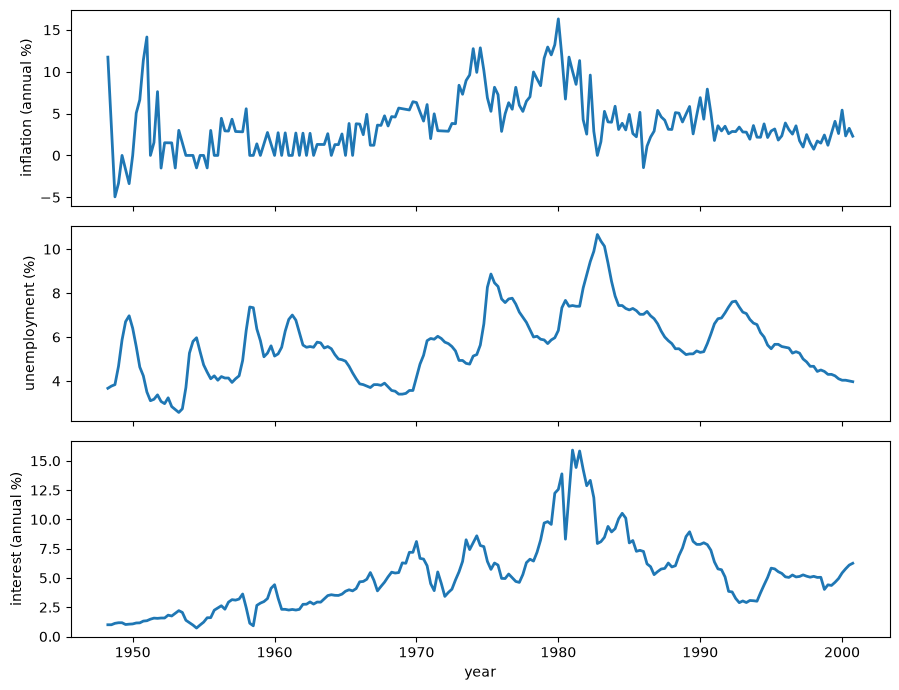

In [6]:
dates_raw = data['raw_dates']
interest = 400 * np.expm1(data['raw_y'][:, 0])
unemployment = 100 * expit(100 * data['raw_y'][:, 1])
inflation = 400 * data['raw_y'][:, 2]

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(dates_raw, inflation, lw=2)
axes[0].set_ylabel('inflation (annual %)')
axes[1].plot(dates_raw, unemployment, lw=2)
axes[1].set_ylabel('unemployment (%)')
axes[2].plot(dates_raw, interest, lw=2)
axes[2].set_ylabel('interest (annual %)')
axes[2].set_xlabel('year')
plt.tight_layout()
plt.show()

通货膨胀和名义利率在20世纪70年代一同上升，并在1980年前后达到峰值；失业率则在反通胀开始之后才达到峰值；而这三个序列在90年代都变得更为平稳。

这些观察结果定位了这一历史事件，但无法说明究竟是系统性动态发生了变化，还是出现了异常大的冲击才导致了这一现象——而这正是本模型所要考察的区别。

## 先验

各参数的先验彼此独立，且被有意设定得较为宽松，用科格利和萨金特的话说，就是要“让数据自由发声”。

它们是根据一个拟合于1948到1958年短训练样本的时不变 VAR 校准得到的。

初始系数先验是一个稳定的、截断的高斯分布，

$$
p(\theta_0) \propto I(\theta_0)N(\bar\theta,\bar P),
$$

其中 $\bar\theta$ 和 $\bar P$ 来自一个拟合于1948—1958训练样本的常系数似不相关回归（SUR）。

由于三个方程具有完全相同的回归变量，SUR 系数估计等于逐方程的OLS估计，这使我们能够简洁地实现这一校准。

In [7]:
def sur_prior(y, x):
    """Calibrate the Gaussian coefficient prior from a constant VAR."""
    xx_inverse = np.linalg.inv(x.T @ x)
    coefficients = xx_inverse @ x.T @ y
    residuals = y - x @ coefficients
    residual_covariance = np.cov(residuals, rowvar=False, ddof=1)
    θ = coefficients.T.reshape(-1)
    covariance = np.kron(residual_covariance, xx_inverse)
    return θ, covariance, residual_covariance


θ_bar, p_bar, r_bar = sur_prior(data['prior_y'], data['prior_x'])

assert is_stable(θ_bar)

系数漂移的协方差具有如下逆威沙特先验

```{math}
:label: csdv_q_prior
Q \sim IW_{21}\left(T_0,T_0\bar Q\right),
\qquad
T_0 = 22,
\qquad
\bar Q = \gamma^2 \bar P,
\qquad
\gamma^2 = 3.5\times 10^{-4}.
```

在 {eq}`csdv_q_prior` 中的约定是先列出自由度，再列出逆威沙特尺度矩阵。

由于 $T_0$ 仅比 $\theta_t$ 的维数大一，这个先验虽然合式（proper），但没有有限均值。

因此矩阵 $\bar Q$ 是一个保守的尺度校准值，而非 $Q$ 的期望。

在后验看到主样本之前，这一校准倾向于支持缓慢的系数漂移。

其余的先验分布为

$$
\begin{aligned}
\log h_{i0} &\sim N(\log \bar R_{ii},10), \\
\beta &\sim N(0,10000I_3), \\
\sigma_i^2 &\sim IG\left(\frac{1}{2},\frac{0.01^2}{2}\right),
\end{aligned}
$$

其中 $\bar R$ 是来自训练样本回归的残差协方差。

下面的函数汇总了这些超参数。

In [8]:
def calibrate_prior(model_data, γ_squared=3.5e-4):
    """Return every calibrated prior for one variable ordering."""
    θ_mean, θ_covariance, residual_covariance = sur_prior(
        model_data['prior_y'], model_data['prior_x']
    )
    degrees_freedom = n_coefficients + 1
    q_center = γ_squared * θ_covariance
    return {
        'θ_mean': θ_mean,
        'θ_covariance': θ_covariance,
        'q_center': q_center,
        'q_scale': degrees_freedom * q_center,
        'q_degrees_freedom': degrees_freedom,
        'log_h_mean': np.log(np.diag(residual_covariance)),
        'log_h_variance': 10.0,
        'β_mean': np.zeros(3),
        'β_variance': 10000.0,
        'σ_degrees_freedom': 1.0,
        'σ_scale': 0.01**2,
        'γ_squared': γ_squared,
    }


prior = calibrate_prior(data)
q_bar = prior['q_center']

prior_summary = pd.Series(
    {
        'dim(θ)': n_coefficients,
        'T0': prior['q_degrees_freedom'],
        'γ squared': prior['γ_squared'],
        'trace(Q bar)': np.trace(q_bar),
        'log-h prior variance': prior['log_h_variance'],
        'β prior variance': prior['β_variance'],
        'σ-squared IG shape': prior['σ_degrees_freedom'] / 2,
        'σ-squared IG scale': prior['σ_scale'] / 2,
    },
    name='value',
)

prior_summary.to_frame()

,value
dim(θ),21.000000
T0,22.000000
γ squared,0.000350
trace(Q bar),0.003004
log-h prior variance,10.000000
β prior variance,10000.000000
σ-squared IG shape,0.500000
σ-squared IG scale,0.000050


(csdv-sampler)=
## 一个 Metropolis-within-Gibbs 抽样器

我们通过遍历 {cite:t}`CogleySargent2005` 所使用的五个参数模块来模拟后验。

遍历全部五个模块一次称为一个扫描（sweep），抽样器要运行多次扫描才能构建出后验样本。

科格利和萨金特模拟不受限制的后验，然后每当某次完整的 MCMC 实现出现爆炸性系数路径时，就丢弃该实现。

但在本例中，只有稳定的扫描才会为保留的受限后验样本贡献实现值。

我们改用 {cite:t}`MurrayAdamsMacKay2010` 的椭圆切片抽样器，在系数路径模块内部施加稳定性限制。

这改变了转移核，但没有改变其目标后验。

1. 通过 Carter—Kohn 前向滤波/后向抽样步骤抽取一条辅助的高斯系数路径，并用它通过椭圆切片抽样来更新稳定路径。

2. 漂移协方差 $Q$ 以系数创新为条件，从一个逆威沙特分布中抽取。

3. 波动率创新方差 $\sigma_i^2$ 以波动率增量为条件，从逆伽马分布中抽取。

4. 协方差参数 $\beta$ 从关于 VAR 残差的两个变换后的高斯回归中抽取。

5. 波动率路径 $H^T$ 通过一个 Jacquier—Polson—Rossi Metropolis 步骤逐日期抽取。

这个顺序很重要：一次扫描中的每个模块都要与它实际所依据的条件值配对。

### 系数路径

以 $R^T$ 和 $Q$ 为条件，一个前向卡尔曼滤波后接 Carter—Kohn 后向模拟器可抽取整条系数路径 {cite}`CarterKohn1994`。

前向步骤是一个卡尔曼滤波，而后向步骤则按 $\theta_T,\theta_{T-1},\ldots,\theta_0$ 的相反顺序抽样，每个状态都以其之后抽出的值为条件。

对 $\theta_0$ 进行抽样是必不可少的。

它为 $Q$ 的共轭更新提供了全部 $T$ 个随机游走增量。

In [9]:
def covariance_root(matrix):
    """Return a numerically stable lower covariance factor."""
    matrix = 0.5 * (matrix + matrix.T)
    scale = max(1.0, np.max(np.abs(np.diag(matrix))))
    return np.linalg.cholesky(matrix + 1e-12 * scale * np.eye(len(matrix)))


def draw_coefficient_path(
    y, x, q, h, β, prior, rng, return_mean=False
):
    """Draw θ_0,...,θ_T and optionally return its smoothing mean."""
    periods = len(y)
    filtered_mean = np.empty((periods + 1, n_coefficients))
    filtered_covariance = np.empty(
        (periods + 1, n_coefficients, n_coefficients)
    )
    predicted_covariance = np.empty_like(filtered_covariance)
    filtered_mean[0] = prior['θ_mean']
    filtered_covariance[0] = prior['θ_covariance']
    predicted_covariance[0] = prior['θ_covariance']
    for t in range(1, periods + 1):
        observation = design_matrix(x[t - 1])
        prediction_covariance = filtered_covariance[t - 1] + q
        r_t = innovation_covariance(h[t], β)
        forecast_covariance = (
            observation @ prediction_covariance @ observation.T + r_t
        )
        gain = linalg.solve(
            forecast_covariance,
            (prediction_covariance @ observation.T).T,
            assume_a='pos',
        ).T
        mean = filtered_mean[t - 1]
        mean = mean + gain @ (y[t - 1] - observation @ mean)
        covariance = (
            prediction_covariance
            - gain @ observation @ prediction_covariance
        )
        covariance = 0.5 * (covariance + covariance.T)
        filtered_mean[t] = mean
        filtered_covariance[t] = covariance
        predicted_covariance[t] = prediction_covariance
    path = np.empty((n_coefficients, periods + 1))
    if not return_mean:
        path[:, -1] = (
            filtered_mean[-1]
            + covariance_root(filtered_covariance[-1])
            @ rng.standard_normal(n_coefficients)
        )
        for t in range(periods - 1, -1, -1):
            smoother = linalg.solve(
                predicted_covariance[t + 1],
                filtered_covariance[t].T,
                assume_a='pos',
            ).T
            mean = filtered_mean[t] + smoother @ (
                path[:, t + 1] - filtered_mean[t]
            )
            covariance = (
                filtered_covariance[t]
                - smoother @ predicted_covariance[t + 1] @ smoother.T
            )
            path[:, t] = mean + covariance_root(covariance) @ (
                rng.standard_normal(n_coefficients)
            )
        return path

    smoothed_mean = np.empty_like(path)
    centered_draw = np.empty_like(path)
    smoothed_mean[:, -1] = filtered_mean[-1]
    centered_draw[:, -1] = covariance_root(filtered_covariance[-1]) @ (
        rng.standard_normal(n_coefficients)
    )
    for t in range(periods - 1, -1, -1):
        smoother = linalg.solve(
            predicted_covariance[t + 1],
            filtered_covariance[t].T,
            assume_a='pos',
        ).T
        smoothed_mean[:, t] = filtered_mean[t] + smoother @ (
            smoothed_mean[:, t + 1] - filtered_mean[t]
        )
        covariance = (
            filtered_covariance[t]
            - smoother @ predicted_covariance[t + 1] @ smoother.T
        )
        centered_draw[:, t] = (
            smoother @ centered_draw[:, t + 1]
            + covariance_root(covariance) @ rng.standard_normal(n_coefficients)
        )
    return smoothed_mean + centered_draw, smoothed_mean


def draw_stable_coefficient_path(
    current, y, x, q, h, β, prior, rng, max_contractions=100
):
    """Elliptical-slice update of the stability-truncated Gaussian path."""
    if not is_stable(current):
        raise ValueError('the elliptical-slice update needs a stable path')
    gaussian_draw, mean = draw_coefficient_path(
        y, x, q, h, β, prior, rng, return_mean=True
    )
    current_centered = current - mean
    innovation = gaussian_draw - mean
    angle = rng.uniform(0, 2 * np.pi)
    lower = angle - 2 * np.pi
    upper = angle
    for contractions in range(max_contractions + 1):
        proposal = (
            mean
            + current_centered * np.cos(angle)
            + innovation * np.sin(angle)
        )
        if is_stable(proposal):
            return proposal, contractions
        if angle < 0:
            lower = angle
        else:
            upper = angle
        angle = rng.uniform(lower, upper)
    raise RuntimeError('elliptical-slice stability bracket did not contract')

### 漂移协方差

以系数增量为条件，$Q$ 具有一个逆威沙特的完全条件分布。

所保留的模拟从一个由其先验尺度和从 $\theta_0$ 到 $\theta_T$ 的全部 $T$ 个平方增量构成的尺度矩阵中抽取 $Q$。

In [10]:
def draw_q(θ_path, prior, rng):
    """Draw Q conditional on the sampled coefficient path."""
    increments = np.diff(θ_path, axis=1)
    scale = prior['q_scale'] + increments @ increments.T
    degrees_freedom = prior['q_degrees_freedom'] + increments.shape[1]
    return invwishart.rvs(df=degrees_freedom, scale=scale, random_state=rng)

### 波动率参数与路径

以波动率增量为条件，每个 $\sigma_i^2$ 具有一个逆伽马完全条件分布。

以 VAR 残差和 $H^T$ 为条件，$B$ 中的自由元素通过两个高斯回归抽取。

以正交化残差为条件，每个波动率状态都用 {cite:t}`Jacquier1994` 提出的单点 Metropolis 步骤进行更新。

随机游走的相邻值决定了对数波动率的高斯提议分布，而对应的正交化残差则决定该提议是否被接受。

以下代码实现了这些条件更新，包括不同的端点提议方式。

In [11]:
def var_residuals(y, x, θ_path):
    """Return residuals with shape (T, 3)."""
    if θ_path.shape[1] == len(y) + 1:
        θ_path = θ_path[:, 1:]
    if θ_path.shape[1] != len(y):
        raise ValueError('θ_path must contain T or T + 1 states')
    coefficients = θ_path.T.reshape(len(y), n_variables, n_regressors)
    fitted = np.einsum('tk,tnk->tn', x, coefficients)
    return y - fitted


def draw_σ(h, prior, rng):
    """Draw the three log-volatility innovation standard deviations."""
    increments = np.diff(np.log(h), axis=0)
    shape = (prior['σ_degrees_freedom'] + increments.shape[0]) / 2
    scales = (prior['σ_scale'] + np.sum(increments**2, axis=0)) / 2
    σ_squared = scales / rng.gamma(shape, 1.0, size=n_variables)
    return np.sqrt(σ_squared)


def draw_β(residuals, h, prior, rng):
    """Draw the free elements of B from transformed Gaussian regressions."""
    β = np.empty(3)
    offset = 0
    for equation in range(1, n_variables):
        standardized = residuals / np.sqrt(h[1:, equation])[:, None]
        dependent = standardized[:, equation]
        regressors = -standardized[:, :equation]
        prior_precision = np.eye(equation) / prior['β_variance']
        covariance = np.linalg.inv(prior_precision + regressors.T @ regressors)
        prior_slice = prior['β_mean'][offset:offset + equation]
        mean = covariance @ (
            prior_precision @ prior_slice + regressors.T @ dependent
        )
        β[offset:offset + equation] = (
            mean + covariance_root(covariance) @ rng.standard_normal(equation)
        )
        offset += equation
    return β


def accept_volatility(proposal, current, residual, rng):
    """Apply the Jacquier--Polson--Rossi likelihood acceptance step."""
    log_ratio = (
        -0.5 * np.log(proposal)
        - residual**2 / (2 * proposal)
        + 0.5 * np.log(current)
        + residual**2 / (2 * current)
    )
    return proposal if np.log(rng.random()) <= min(0.0, log_ratio) else current


def draw_volatility_path(h, residuals, β, σ, prior, rng):
    """Update all stochastic-volatility states one date at a time."""
    periods = len(residuals)
    orthogonalized = (b_matrix(β) @ residuals.T).T
    updated = np.empty_like(h)
    for equation in range(n_variables):
        variance = σ[equation]**2
        initial_variance = (
            prior['log_h_variance'] * variance
            / (variance + prior['log_h_variance'])
        )
        initial_mean = initial_variance * (
            prior['log_h_mean'][equation] / prior['log_h_variance']
            + np.log(h[1, equation]) / variance
        )
        updated[0, equation] = np.exp(
            initial_mean + np.sqrt(initial_variance) * rng.standard_normal()
        )
        for t in range(1, periods):
            mean = 0.5 * (
                np.log(updated[t - 1, equation]) + np.log(h[t + 1, equation])
            )
            proposal = np.exp(
                mean + np.sqrt(variance / 2) * rng.standard_normal()
            )
            updated[t, equation] = accept_volatility(
                proposal,
                h[t, equation],
                orthogonalized[t - 1, equation],
                rng,
            )
        proposal = np.exp(
            np.log(updated[-2, equation])
            + σ[equation] * rng.standard_normal()
        )
        updated[-1, equation] = accept_volatility(
            proposal,
            h[-1, equation],
            orthogonalized[-1, equation],
            rng,
        )
    return updated

### 完整的抽样器

受限后验对在任何日期（包括 $\theta_0$）出现爆炸性的系数路径都赋予零密度。

将整条系数路径 $\theta_0,\ldots,\theta_T$ 堆叠成 $z$，并把其余的参数模块收集在
$\lambda=(Q,H^T,\beta,\sigma)$ 中。

以 $\lambda$ 和数据 $Y^T$ 为条件，不受限制的 Carter—Kohn 分布是一个均值为
$m$、协方差为 $C$ 的高斯分布，

$$
z\mid \lambda,Y^T \sim N(m,C).
$$

设 $\mathcal A$ 为在每个日期其伴随根都严格位于单位圆内的路径集合，那么受限的完全条件就是这个截断到 $\mathcal A$ 上的高斯分布，

$$
\pi_{\mathcal A}(z\mid\lambda,Y^T)
= \frac{N(z;m,C)\,\mathbb{1}_{\mathcal A}(z)}
       {\mathbb{P}\{z\in\mathcal A\mid\lambda,Y^T\}}.
$$

那个归一化概率难以计算，但椭圆转移从不需要对它求值。

科格利和萨金特转而模拟不受限制的联合后验，并只有在整条路径都稳定时才保留一个实现值，这是有效的，因为在不受限制的后验上以 $z\in\mathcal A$ 为条件恰好精确地重现了受限后验。

如果用 $a$ 表示一条路径不受限制时是稳定的概率，那么这种拒绝方案对每一个保留的抽样大约需要 $1/a$ 次完整的扫描，其中还包括其余四个参数的更新。

椭圆切片抽样器通过在稳定区域内部移动而非从任意抽样重新开始，避免了这种浪费。

它从当前的稳定路径 $z^{(c)}$ 和一个新抽取的 Carter—Kohn
样本 $\widetilde z\sim N(m,C)$ 出发，其中心化版本
$\nu=\widetilde z-m$ 与 $z^{(c)}$ 一起描绘出一个椭圆，

$$
z(\phi)
=m+(z^{(c)}-m)\cos\phi+\nu\sin\phi,
\qquad 0\leq\phi<2\pi,
$$

因此 $z(0)=z^{(c)}$ 且 $z(\pi/2)=\widetilde z$。

该算法从整个圆周上均匀地抽取一个角度，每当 $z(\phi)$ 是爆炸性的，就把括号（bracket）收缩到包含已知稳定角度 $\phi=0$ 的那一侧，然后再重新抽取。

由于伴随根随系数连续变化，$\phi=0$ 周围总存在一个非零区间是稳定的，因此这一括号搜索总能终止。

每一个被拒绝的角度只花费一次线性组合运算和一次伴随根检验的代价，比再执行一次卡尔曼滤波和后向模拟便宜得多。

该转移是有效的，因为将配对 $(z^{(c)}-m,\nu)$ 旋转任意角度都不会改变它们的联合高斯密度，因此这一搜索沿着一条固定轨道移动，在这条轨道上每一点在不受限制的密度下都是等可能的。

稳定性指示函数在标准椭圆切片更新中扮演着似然函数的角色，并且由于它在当前点处等于一，每一个被接受的角度都自动是稳定的，无需再进行单独的切片高度抽样。

将辅助路径边缘化后可以证明，这一转移使截断的高斯分布
$N(z;m,C)\mathbb{1}_{\mathcal A}(z)$ 保持不变，这正是一个有效转移核所需要具备的性质。

其余四个模块不需要这样的调整。

以一个稳定的 $z$ 为条件，稳定性指示函数在
$Q,H^T,\beta$ 和 $\sigma$ 上都是常数，因此它会从它们各自的完全条件中约去，留下的更新与不受限制的抽样器相同。

$Q$ 的条件分布在形式上没有变化，但由于每次抽取的 $Q$ 都以一条稳定的系数路径为条件，其边际后验仍然会向不那么爆炸性的漂移倾斜。

综合起来，对 $z$ 的椭圆转移，以及对
$Q,H^T,\beta$ 和 $\sigma$ 不加改变的更新，以远低于科格利和萨金特原始拒绝抽样器的代价，瞄准同一个受稳定性限制的后验。

下面这个函数将这五个模块组合在一起，并包含一个随机波动率的预热阶段。

In [12]:
def initial_volatilities(y, prior):
    """Construct the sampler's initial volatility path."""
    changes = np.diff(y, axis=0)
    centered = changes - changes.mean(axis=0)
    log_h = np.empty((len(y) + 1, n_variables))
    log_h[:2] = prior['log_h_mean']
    log_h[2:] = np.log(np.maximum(centered**2, np.finfo(float).tiny))
    return np.exp(log_h)


def run_sampler(
    y,
    x,
    prior,
    n_sweeps=1_000,
    burn=500,
    thin=1,
    seed=42,
    warmup=200,
    max_contractions=100,
    stable=True,
    fixed_q=None,
    retain=('S0D', 'SD', 'QD', 'HD', 'CD', 'VD', 'stable_draw'),
    progress_every=0,
):
    """Run a Gibbs sampler for the unrestricted or stable posterior.

    For the stable posterior, an elliptical-slice transition updates the FFBS
    path inside its stability-truncated Gaussian full conditional.  Passing
    ``fixed_q`` holds Q at that value (for example a matrix of zeros) instead of
    drawing it, which nests the constant-coefficient model.
    """
    if not (0 <= burn < n_sweeps and thin >= 1):
        raise ValueError('require 0 <= burn < n_sweeps and thin >= 1')
    if (n_sweeps - burn) % thin:
        raise ValueError('(n_sweeps - burn) must be divisible by thin')
    valid_retain = {'S0D', 'SD', 'QD', 'HD', 'CD', 'VD', 'stable_draw'}
    unknown = set(retain) - valid_retain
    if unknown:
        raise ValueError(f'unknown retained arrays: {sorted(unknown)}')

    started = time.perf_counter()
    rng = np.random.default_rng(seed)
    h = initial_volatilities(y, prior)
    β = prior['β_mean'].copy()
    warm_θ = np.repeat(prior['θ_mean'][:, None], len(y), axis=1)
    warm_residuals = var_residuals(y, x, warm_θ)
    for _ in range(warmup):
        σ = draw_σ(h, prior, rng)
        β = draw_β(warm_residuals, h, prior, rng)
        h = draw_volatility_path(
            h, warm_residuals, β, σ, prior, rng
        )

    q = (
        prior['q_center'].copy()
        if fixed_q is None
        else np.array(fixed_q, dtype=float)
    )
    θ = np.repeat(
        prior['θ_mean'][:, None], len(y) + 1, axis=1
    )
    if stable and not is_stable(θ):
        raise ValueError('the prior mean does not provide a stable start')
    slice_contractions = 0
    maximum_slice_contractions = 0

    retained = {name: [] for name in retain}
    saved_stability = []
    for sweep in range(1, n_sweeps + 1):
        if stable:
            θ, contractions = draw_stable_coefficient_path(
                θ,
                y,
                x,
                q,
                h,
                β,
                prior,
                rng,
                max_contractions=max_contractions,
            )
        else:
            θ = draw_coefficient_path(y, x, q, h, β, prior, rng)
            contractions = 0
        slice_contractions += contractions
        maximum_slice_contractions = max(
            maximum_slice_contractions, contractions
        )
        if fixed_q is None:
            q = draw_q(θ, prior, rng)
        residuals = var_residuals(y, x, θ)
        σ = draw_σ(h, prior, rng)
        β = draw_β(residuals, h, prior, rng)
        h = draw_volatility_path(
            h, residuals, β, σ, prior, rng
        )

        if sweep > burn and (sweep - burn) % thin == 0:
            path_is_stable = is_stable(θ)
            saved_stability.append(path_is_stable)
            values = {
                'S0D': θ[:, 0],
                'SD': θ[:, 1:],
                'QD': q,
                'HD': h,
                'CD': β,
                'VD': σ,
                'stable_draw': path_is_stable,
            }
            for name in retained:
                retained[name].append(np.asarray(values[name]).copy())

        if progress_every and sweep % progress_every == 0:
            elapsed = time.perf_counter() - started
            print(
                f'{sweep:,}/{n_sweeps:,} sweeps; '
                f'{slice_contractions:,} slice contractions; '
                f'{elapsed / 60:.1f} minutes',
                flush=True,
            )

    stack_axis = {
        'S0D': 1,
        'SD': 2,
        'QD': 2,
        'HD': 2,
        'CD': 1,
        'VD': 1,
        'stable_draw': 0,
    }
    result = {
        name: np.stack(values, axis=stack_axis[name])
        for name, values in retained.items()
    }
    result['diagnostics'] = {
        'sampler_version': 3,
        'seed': int(seed),
        'stable_restriction': bool(stable),
        'n_sweeps': int(n_sweeps),
        'burn': int(burn),
        'thin': int(thin),
        'warmup': int(warmup),
        'retained_draws': int((n_sweeps - burn) // thin),
        'slice_contractions': int(slice_contractions),
        'mean_slice_contractions': float(slice_contractions / n_sweeps),
        'maximum_slice_contractions': int(maximum_slice_contractions),
        'retained_stability_rate': float(np.mean(saved_stability)),
        'elapsed_seconds': float(time.perf_counter() - started),
    }
    return result

下面这个可执行的版本使用1,000次扫描，丢弃前500次，保留其余的500次。

它使用了完整的历史样本，采用 $(i,u,\pi)$ 的排序。

我们没有运行一次大型的 MCMC 实验，而是有意让抽样器运行规模较小，以便在讲座中能在合理时间内完成。

这次简短的运行说明了该方法，但并非一次数值上的复现。

不过后验的主要定性特征与科格利和萨金特所报告的结果相近。

In [13]:
posterior = run_sampler(
    data['y'],
    data['x'],
    prior,
    n_sweeps=1_000,
    burn=500,
    thin=1,
    seed=42,
    warmup=200,
    stable=True,
    progress_every=0,
)

def validate_posterior_arrays(result, periods):
    """Check posterior shapes, finiteness, positivity, and stability."""
    draws = result['diagnostics']['retained_draws']
    expected = {
        'S0D': (n_coefficients, draws),
        'SD': (n_coefficients, periods, draws),
        'QD': (n_coefficients, n_coefficients, draws),
        'HD': (periods + 1, n_variables, draws),
        'CD': (3, draws),
        'VD': (3, draws),
        'stable_draw': (draws,),
    }
    assert {name: result[name].shape for name in expected} == expected
    assert all(np.all(np.isfinite(result[name])) for name in expected)
    assert np.all(result['HD'] > 0)
    assert np.all(result['VD'] > 0)
    assert np.all(result['stable_draw'])
    return expected


expected_shapes = validate_posterior_arrays(posterior, len(data['dates']))

(csdv-results)=
## 数据揭示了什么

我们用后验均值系数路径 $\mathbb{E}(\theta_t\mid T)$ 和后验均值协方差路径
$\mathbb{E}(R_t\mid T)$ 来总结后验，然后在我们所提出问题的背景下对其加以解释。

### 漂移的速率与结构

$Q$ 的迹衡量的是系数漂移的总体速率，$\operatorname{tr}(Q)=0$ 对应于系数恒定不变的情形。

直方图展示了保留下来的 $Q$ 抽样以及先验尺度。

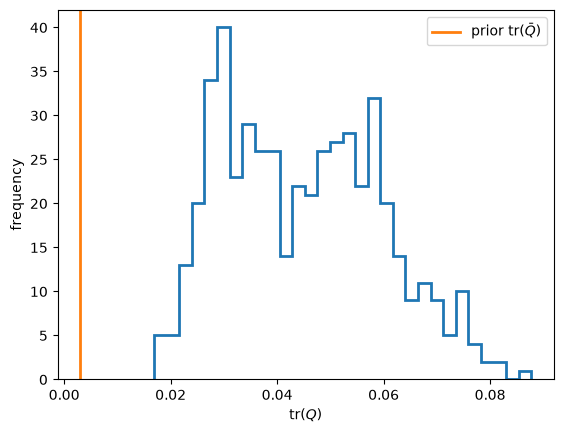

In [14]:
trace_q = np.trace(posterior['QD'], axis1=0, axis2=1)
fig, ax = plt.subplots()
ax.hist(trace_q, bins=30, histtype='step', lw=2)
ax.axvline(np.trace(q_bar), color='C1', lw=2,
           label=r'prior $\mathrm{tr}(\bar Q)$')
ax.set_xlabel(r'$\mathrm{tr}(Q)$')
ax.set_ylabel('frequency')
ax.legend()
plt.show()

后验漂移速率明显高于保守的先验校准值，表明系数变动幅度大于该校准值所预期的水平。

这并非与固定系数模型的正式比较，因为连续先验没有在 $Q=0$ 处赋予任何点质量。

在已拟合的 TVP-VAR 模型内部，这种变动被归因于系统性关系的变化；它并不能确定政策就是其原因。

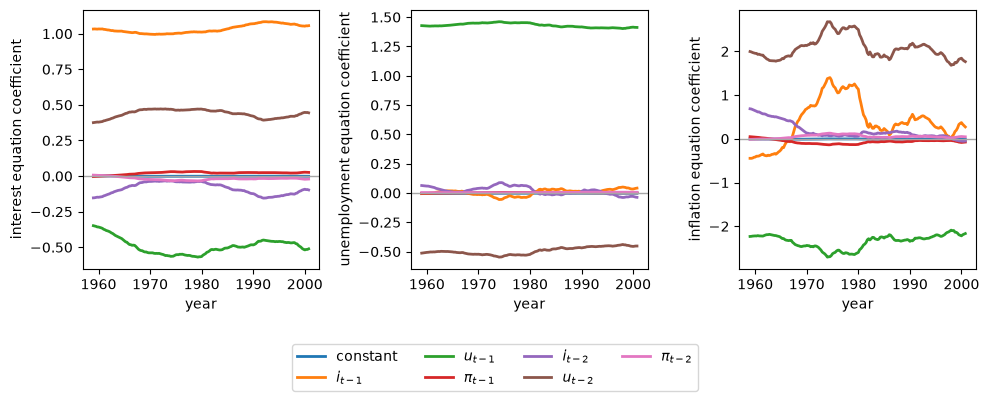

In [15]:
θ_mean = posterior['SD'].mean(axis=2)
mean_path_root_modulus = np.max(
    np.abs(companion_roots(θ_mean)), axis=1
)
assert np.all(mean_path_root_modulus < 1)
coefficient_labels = (
    'constant',
    r'$i_{t-1}$',
    r'$u_{t-1}$',
    r'$\pi_{t-1}$',
    r'$i_{t-2}$',
    r'$u_{t-2}$',
    r'$\pi_{t-2}$',
)
equation_labels = (
    'interest equation',
    'unemployment equation',
    'inflation equation',
)


def plot_equation_coefficients(axes, dates, θ_path):
    """Plot seven labeled coefficients for each VAR equation."""
    first_lines = None
    for equation, (ax, label) in enumerate(zip(axes, equation_labels)):
        start = equation * len(coefficient_labels)
        stop = start + len(coefficient_labels)
        lines = ax.plot(dates, θ_path[start:stop].T, lw=2)
        for line, coefficient_label in zip(lines, coefficient_labels):
            line.set_label(coefficient_label)
        if first_lines is None:
            first_lines = lines
        ax.axhline(0, color='0.65', lw=1)
        ax.set_xlabel('year')
        ax.set_ylabel(f'{label} coefficient')
    return first_lines


fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharex=True)
coefficient_lines = plot_equation_coefficients(
    axes,
    data['dates'],
    θ_mean,
)
fig.legend(
    coefficient_lines,
    coefficient_labels,
    loc='lower center',
    ncol=4,
)
plt.tight_layout(rect=(0, 0.17, 1, 1))
plt.show()

失业方程相对稳定，而通货膨胀方程中的若干系数在整个70年代剧烈波动，并在1980年前后出现转折。

因此，漂移主要集中在通货膨胀如何传播这一方面，而非均匀分布在整个 VAR 中，并且不应对单个滞后系数做出结构性解释，因为成对的滞后项可能相互抵消。

我们针对排序 $(i,u,\pi)$ 来总结漂移情况，该排序具有最小的稳定后验均值 $\operatorname{tr}(Q)$。

In [16]:
trace_q = np.trace(posterior['QD'], axis1=0, axis2=1)
q_mean = posterior['QD'].mean(axis=2)
drift_summary = {
    r'\text{Posterior mean } \operatorname{tr}(Q)': np.trace(q_mean),
    r'\text{Posterior mean largest eigenvalue}': (
        np.linalg.eigvalsh(q_mean)[-1]
    ),
    r'\text{Prior } \operatorname{tr}(\bar Q)': np.trace(q_bar),
}
drift_rows = ' \\\\\n'.join(
    f'{label} & {value:.4f}' for label, value in drift_summary.items()
)
display(Math(rf'''
\begin{{array}}{{lr}}
\text{{Quantity}} & \text{{Estimate}} \\
\hline
{drift_rows}
\end{{array}}
'''))

<IPython.core.display.Math object>

科格利和萨金特对每一种排序都做了估计。

他们的后验均值表明，排序的改变会影响数值大小，但不会消除漂移：

| Ordering | Stable $\operatorname{tr}(Q)$ | Stable $\max(\lambda)$ | Unrestricted $\operatorname{tr}(Q)$ | Unrestricted $\max(\lambda)$ |
|---|---:|---:|---:|---:|
| $(i,\pi,u)$ | 0.055 | 0.025 | 0.056 | 0.027 |
| $(i,u,\pi)$ | 0.047 | 0.023 | 0.059 | 0.031 |
| $(\pi,i,u)$ | 0.064 | 0.031 | 0.082 | 0.044 |
| $(\pi,u,i)$ | 0.062 | 0.031 | 0.088 | 0.051 |
| $(u,i,\pi)$ | 0.057 | 0.026 | 0.051 | 0.028 |
| $(u,\pi,i)$ | 0.055 | 0.024 | 0.072 | 0.035 |

对于使 $Q$ 最小的排序而言，去掉稳定性限制会提高后验均值漂移速率，如上表所示。

后文的分析采用 $(i,u,\pi)$ 排序，即将名义利率排在首位、通货膨胀排在末位。

对 $Q$ 的后验均值进行对角化后可以发现，漂移是低维的。

以下的特征分解总结了 $Q$ 的后验均值。

In [17]:
q_mean = posterior['QD'].mean(axis=2)
q_eigenvalues = np.linalg.eigvalsh(q_mean)[::-1]
q_cumulative = np.cumsum(q_eigenvalues) / q_eigenvalues.sum()

drift_structure = pd.DataFrame(
    {
        'eigenvalue': q_eigenvalues[:3],
        'cumulative share': q_cumulative[:3],
    },
    index=pd.Index(range(1, 4), name='principal component'),
)
drift_structure.round(4)

,eigenvalue,cumulative share
principal component,,
1,0.0264,0.5875
2,0.0156,0.9339
3,0.0013,0.9625


即使 VAR 包含21个系数，前三个主成分也占据了系数漂移总量中的大多数。

### 波动率的演变

我们首先要问的是，冲击的*大小*是如何变化的。

方程 {eq}`csdv_covariance` 可以在各次抽样之间取平均，而无需构造一个四维的协方差数组。

In [18]:
def mean_innovation_covariance(h_draws, β_draws):
    """Compute E(R_t | T) with working memory proportional to T times D."""
    n_draws = h_draws.shape[2]
    matrices = np.broadcast_to(np.eye(3), (n_draws, 3, 3)).copy()
    matrices[:, 1, 0] = β_draws[0]
    matrices[:, 2, 0] = β_draws[1]
    matrices[:, 2, 1] = β_draws[2]
    inverses = np.linalg.solve(
        matrices,
        np.broadcast_to(np.eye(3), matrices.shape),
    )
    h = h_draws[1:]
    mean = np.empty((h.shape[0], 3, 3))
    for row in range(3):
        for column in range(row + 1):
            value = np.zeros(h.shape[0])
            for shock in range(3):
                weights = inverses[:, row, shock] * inverses[:, column, shock]
                value += h[:, shock, :] @ weights
            mean[:, row, column] = value / n_draws
            mean[:, column, row] = mean[:, row, column]
    return mean


r_mean = mean_innovation_covariance(posterior['HD'], posterior['CD'])

下图展示了创新标准差和相关系数。

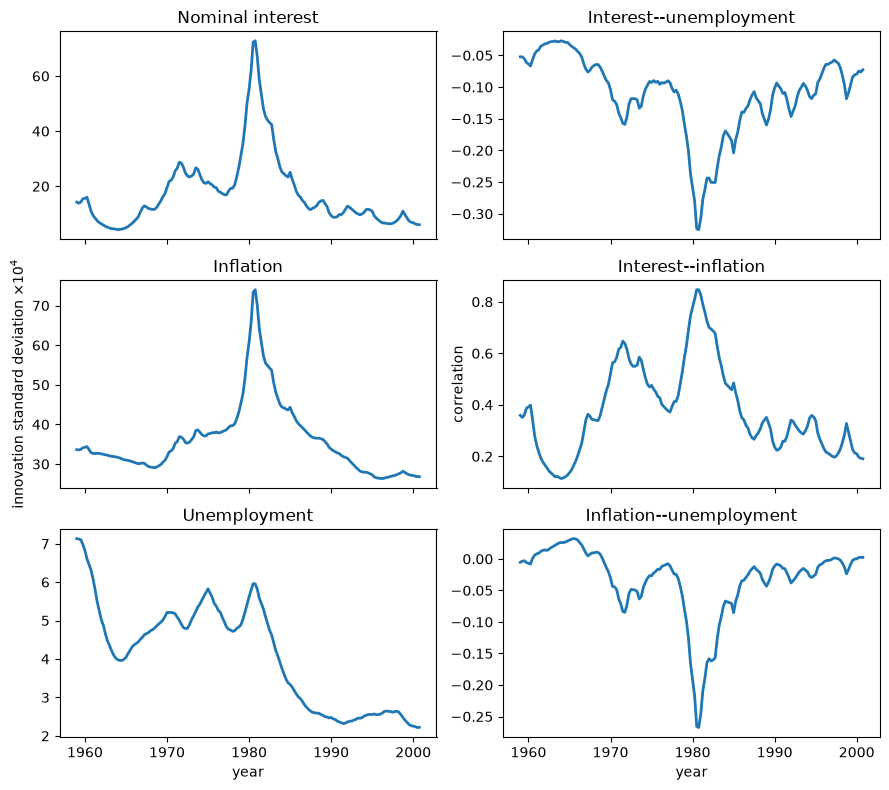

In [19]:
variances = ((0, 'Nominal interest'), (2, 'Inflation'), (1, 'Unemployment'))
correlations = (
    (0, 1, 'Interest--unemployment'),
    (0, 2, 'Interest--inflation'),
    (2, 1, 'Inflation--unemployment'),
)
fig, axes = plt.subplots(3, 2, figsize=(9, 8), sharex=True)
for row, (index, label) in enumerate(variances):
    axes[row, 0].plot(
        data['dates'], 10000 * np.sqrt(r_mean[:, index, index]), lw=2
    )
    axes[row, 0].set_title(label)
for row, (left, right, label) in enumerate(correlations):
    scale = np.sqrt(r_mean[:, left, left] * r_mean[:, right, right])
    axes[row, 1].plot(data['dates'], r_mean[:, left, right] / scale, lw=2)
    axes[row, 1].set_title(label)
axes[1, 0].set_ylabel(
    r'innovation standard deviation $\times 10^4$'
)
axes[1, 1].set_ylabel('correlation')
axes[-1, 0].set_xlabel('year')
axes[-1, 1].set_xlabel('year')
plt.tight_layout()
plt.show()

利率和通货膨胀创新标准差在1980年前后急剧达到峰值，而失业创新波动率则在样本末段更为渐进地下降。

这三种创新的相关系数也都在1980年前后发生最剧烈的变动，因此简化形式冲击的大小和联合构成都发生了变化。

这些变动为“运气变化”即“运气不好”的解释赋予了重要地位，尽管利率创新本身并非结构性货币政策冲击。

后验均值协方差矩阵的对数行列式总结了广义单步创新方差 {cite}`Whittle1953`。

以下变换总结了广义创新方差。

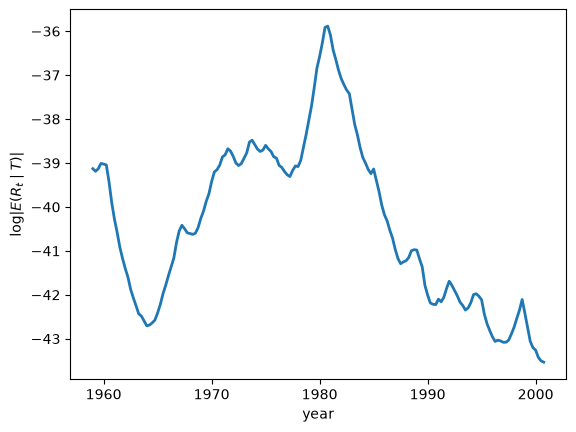

In [20]:
sign, logdet_r = np.linalg.slogdet(r_mean)
assert np.all(sign > 0)
fig, ax = plt.subplots()
ax.plot(data['dates'], logdet_r, lw=2)
ax.set_xlabel('year')
ax.set_ylabel(r'$\log |E(R_t\mid T)|$')
plt.show()

由于对数行列式越不为负数意味着联合创新方差越大，从两阶段上升到1981年异常峰值、再到随后长期下降，标志着一次大规模冲击事件，随后是由 {cite:t}`KimNelson1999` 和 {cite:t}`McConnellPerezQuiros2000` 记录的“大缓和”（Great Moderation）时期。

这是关于运气变化最清晰的总体证据，但它无法解释接下来要考察的、以系数为基础的通货膨胀动态变化。

### 核心通货膨胀与自然失业率

为了研究系统性动态，我们把 $t$ 期的 VAR 用伴随形式写成

$$
z_t = \mu_{t\mid T} + A_{t\mid T}z_{t-1} + e_t.
$$

在日期 $t$，局部均值 $m_t$ 是这样一个不动点：如果伴随形式的 VAR 系数固定在其后验均值处，且未来的创新为零，系统将收敛到该点。

```{math}
:label: csdv_local_means
m_t = (I-A_{t\mid T})^{-1}\mu_{t\mid T},
\qquad
\bar\pi_t = 4s_\pi m_t,
\qquad
\bar u_t = \frac{\exp(100s_u m_t)}{1+\exp(100s_u m_t)}.
```

这里 $s_\pi$ 和 $s_u$ 从 $m_t$ 中选取通货膨胀和失业率，因子四对通货膨胀进行年化，逆 logit 变换则将失业率还原为观测到的比率。

这些是被冻结的局部系统在特定日期的稳态，而非整体漂移过程的无条件均值。

核心通货膨胀是冻结 $t$ 期系数所隐含的长期通货膨胀预测，而自然失业率则是相应的长期失业率锚点，而非自然利率，也不是下一季度失业率的预测值。

冻结当前系数并向前推算，恰恰是 {doc}`phillips_learning` 和 {doc}`phillips_escaping_nash` 中学习型政府所采用的*预期效用*（anticipated-utility）手法，这些政府的行为就好像自己当前的信念永远不会被修正一样。

以下的实现对核心通货膨胀进行了年化处理，并将存档数据中的失业率变换加以还原。

In [21]:
def local_means(θ_path):
    """Compute local core inflation and the natural unemployment rate."""
    θ_path = np.asarray(θ_path, dtype=float)
    if θ_path.ndim == 1:
        θ_path = θ_path[:, None]
    core = np.empty(θ_path.shape[1])
    natural = np.empty(θ_path.shape[1])
    for t in range(θ_path.shape[1]):
        intercept, companion = companion_matrix(θ_path[:, t])
        mean = np.linalg.solve(np.eye(6) - companion, intercept)
        core[t] = 4 * mean[2]
        natural[t] = expit(100 * mean[1])
    return core, natural


core_inflation, natural_rate = local_means(θ_mean)

我们绘制每年第四季度的观测值。

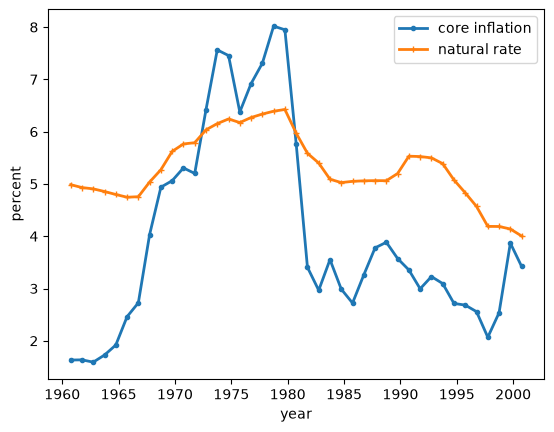

In [22]:
def annual_indices(dates, start=1960):
    """Return the final observation in each year from a start date."""
    year_values = np.floor(dates + 1e-8).astype(int)
    return np.array(
        [
            np.flatnonzero(year_values == year)[-1]
            for year in np.unique(year_values)
            if year >= start
        ]
    )


years = np.floor(data['dates'] + 1e-8).astype(int)
annual = annual_indices(data['dates'])

fig, ax = plt.subplots()
ax.plot(data['dates'][annual], 100 * core_inflation[annual], 'o-', lw=2,
        markersize=3, label='core inflation')
ax.plot(data['dates'][annual], 100 * natural_rate[annual], '+-', lw=2,
        markersize=5, label='natural rate')
ax.set_xlabel('year')
ax.set_ylabel('percent')
ax.legend()
plt.show()

In [23]:
core_summary = pd.Series(
    {
        'early-1960s mean core inflation (%)': (
            100 * core_inflation[(years >= 1960) & (years <= 1964)].mean()
        ),
        'peak core inflation (%)': 100 * core_inflation[annual].max(),
        '1985--2000 mean core inflation (%)': (
            100 * core_inflation[(years >= 1985) & (years <= 2000)].mean()
        ),
    },
    name='estimate',
)
core_summary.to_frame().round(2)

,estimate
early-1960s mean core inflation (%),1.67
peak core inflation (%),8.02
1985--2000 mean core inflation (%),3.09


核心通货膨胀从60年代初的低水平攀升到1980年前后的高峰，然后回落；而自然失业率则从约5%更为平缓地上升到6.5%左右，随后又回落到接近4%的水平。

由于这两条曲线都由拟合的系数决定，而非由实现的冲击决定，它们的持续性变化指向了一个不断变化的系统性成分。

以下计算总结了它们在整个后验样本内的共同变动情况。

In [24]:
core_natural_correlation = np.corrcoef(core_inflation, natural_rate)[0, 1]

core_natural_correlation

np.float64(0.8375125179331293)

$\bar\pi_t$ 与 $\bar u_t$ 之间强烈的正季度相关性表明，模型所隐含的长期通货膨胀和失业率锚点共享一个宽泛的周期，而并不意味着当前的通货膨胀与当前的失业率必须同向变动。

由于当最大根接近于一时，$(I-A_t)^{-1}$ 会放大微小的系数变化，长期均值本质上比短期预测更为敏感。

### 通货膨胀的持续性

我们现在要问的是，除了不断变动的波动率之外，系统性动态本身是否也发生了漂移。

主要的总结指标是通货膨胀持续性，用零频率处通货膨胀的归一化谱来衡量。

日期 $t$ 处通货膨胀的谱密度为

```{math}
:label: csdv_spectrum
f_{\pi\pi}(\omega,t)
=
\frac{1}{2\pi}
s_\pi
(I-A_{t\mid T}e^{-i\omega})^{-1}
\mathcal R_t
(I-A_{t\mid T}^\top e^{i\omega})^{-1}
s_\pi^\top,
```

其中 $\mathcal R_t$ 将 $\mathbb{E}(R_t\mid T)$ 嵌入伴随系统中。

低频功率既取决于自回归系数，也取决于创新协方差。

下面这个函数计算任意以每季度周期数表示的频率下的通货膨胀功率，并且还返回日期 $t$ 的通货膨胀方差。

In [25]:
def inflation_spectrum(θ, covariance, frequencies):
    """Compute inflation power and its variance-normalized counterpart."""
    _, companion = companion_matrix(θ)
    innovation = np.zeros((6, 6))
    innovation[:3, :3] = covariance
    selector = np.zeros(6)
    selector[2] = 1
    stationary = linalg.solve_discrete_lyapunov(companion, innovation)
    variance = float(selector @ stationary @ selector)
    power = np.empty(len(frequencies))
    for index, frequency in enumerate(frequencies):
        phase = np.exp(-2j * np.pi * frequency)
        transfer = np.linalg.solve(np.eye(6) - companion * phase, np.eye(6))
        power[index] = np.real(
            selector @ transfer @ innovation @ transfer.conj().T @ selector
        ) / (2 * np.pi)
    return power, power / variance


归一化谱除以日期 $t$ 的通货膨胀方差，

```{math}
:label: csdv_normalized_spectrum
g_{\pi\pi}(\omega,t)
=
\frac{f_{\pi\pi}(\omega,t)}
{\int_{-\pi}^{\pi}f_{\pi\pi}(\omega,t)d\omega},
```

因此 $g_{\pi\pi}(0,t)$ 是一个基于自相关的持续性度量。

这一归一化去除了 $R_t$ 的一个公共尺度因子，但它仍可能依赖于 $R_t$ 中的相对方差和协方差。

第一张图单独展示了零频率处作为一维持续性总结的取值。

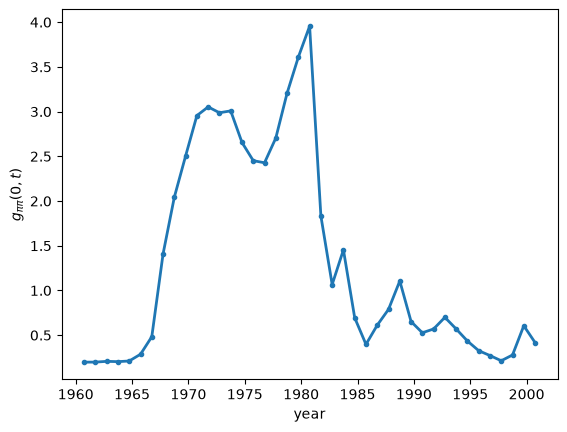

In [26]:
zero_frequency = np.array([0.0])
inflation_persistence = np.array([
    inflation_spectrum(θ_mean[:, t], r_mean[t], zero_frequency)[1][0]
    for t in range(len(data['dates']))
])

fig, ax = plt.subplots()
ax.plot(
    data['dates'][annual],
    inflation_persistence[annual],
    'o-',
    lw=2,
    markersize=3,
)
ax.set_xlabel('year')
ax.set_ylabel(r'$g_{\pi\pi}(0,t)$')
plt.show()

In [27]:
persistence_summary = pd.Series(
    {
        '1960--64 mean': inflation_persistence[
            (years >= 1960) & (years <= 1964)
        ].mean(),
        '1970--79 mean': inflation_persistence[
            (years >= 1970) & (years <= 1979)
        ].mean(),
        '1985--2000 mean': inflation_persistence[
            (years >= 1985) & (years <= 2000)
        ].mean(),
        'peak': inflation_persistence[annual].max(),
        'peak year': years[annual][np.argmax(inflation_persistence[annual])],
    },
    name='estimate',
)
persistence_summary.to_frame().round(3)

,estimate
1960--64 mean,0.204
1970--79 mean,2.865
1985--2000 mean,0.537
peak,3.956
peak year,1980.000


归一化的零频率功率从60年代初的低水平急剧上升，在1980年前后达到高峰，然后在样本剩余的大部分时间里回落到一以下。

1980年后的这一崩溃不能用对所有创新进行一次比例缩放来解释，尽管这一归一化统计量仍可能取决于 $R_t$ 的组成。

作为比较，一个系数为 $\rho$ 的 $AR(1)$ 过程具有归一化零频率功率
$(1+\rho)/[2\pi(1-\rho)]$。

介于2和10之间的取值对应于 $\rho$ 在约 $0.85$ 到
$0.97$ 之间。

零频率路径省略了频率分布的其余部分。

下面的热力图展示了原始和方差归一化的通货膨胀功率如何随时间和频率两个维度变化。

In [28]:
def inflation_spectrum_surface(θ_path, covariance_path, frequencies):
    """Evaluate the inflation spectrum at each date on a frequency grid."""
    raw = np.empty((len(frequencies), θ_path.shape[1]))
    normalized = np.empty_like(raw)
    for date in range(θ_path.shape[1]):
        raw[:, date], normalized[:, date] = inflation_spectrum(
            θ_path[:, date],
            covariance_path[date],
            frequencies,
        )
    return raw, normalized


spectrum_frequencies = np.linspace(0, 0.5, 41)
raw_spectrum, normalized_spectrum = inflation_spectrum_surface(
    θ_mean,
    r_mean,
    spectrum_frequencies,
)

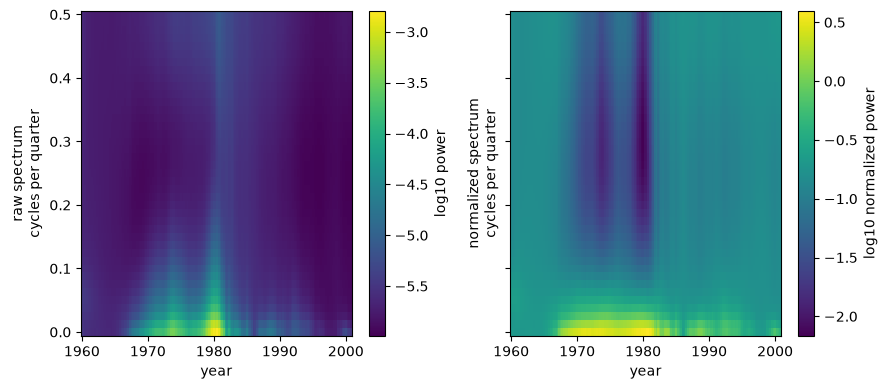

In [29]:
spectrum_start = data['dates'] >= 1960
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
surfaces = (
    (raw_spectrum, 'raw spectrum', 'log10 power'),
    (normalized_spectrum, 'normalized spectrum', 'log10 normalized power'),
)
for ax, (surface, title, color_label) in zip(axes, surfaces):
    image = ax.pcolormesh(
        data['dates'][spectrum_start],
        spectrum_frequencies,
        np.log10(surface[:, spectrum_start]),
        shading='auto',
    )
    ax.set_xlabel('year')
    ax.set_ylabel(f'{title}\ncycles per quarter')
    fig.colorbar(image, ax=ax, label=color_label)
plt.tight_layout()
plt.show()

原始谱在1980年前后靠近零频率的区域最为明亮，因为冲击和持续性都被放大了；而归一化谱则在整个70年代保留了一条宽泛的低频“脊”，并在1980年之后消退。

这条在归一化后依然存在的“脊”表明，大通胀不仅仅是一个高波动率的事件，因为通货膨胀冲击也以更持久的方式传播开来。

点估计并不能揭示数据对这些路径的确定程度有多强。

因此我们从每一个保留的抽样中计算相同的年度特征。

In [30]:
def posterior_feature_draws(result, indices):
    """Compute selected local means and persistence for retained draws."""
    n_draws = result['SD'].shape[2]
    shape = (len(indices), n_draws)
    core = np.empty(shape)
    natural = np.empty(shape)
    persistence = np.empty(shape)
    for draw in range(n_draws):
        core[:, draw], natural[:, draw] = local_means(
            result['SD'][:, indices, draw]
        )
        for row, date in enumerate(indices):
            covariance = innovation_covariance(
                result['HD'][date + 1, :, draw],
                result['CD'][:, draw],
            )
            persistence[row, draw] = inflation_spectrum(
                result['SD'][:, date, draw],
                covariance,
                zero_frequency,
            )[1][0]
    return {
        'core': 100 * core,
        'natural': 100 * natural,
        'persistence': persistence,
    }


historical_feature_draws = posterior_feature_draws(posterior, annual)

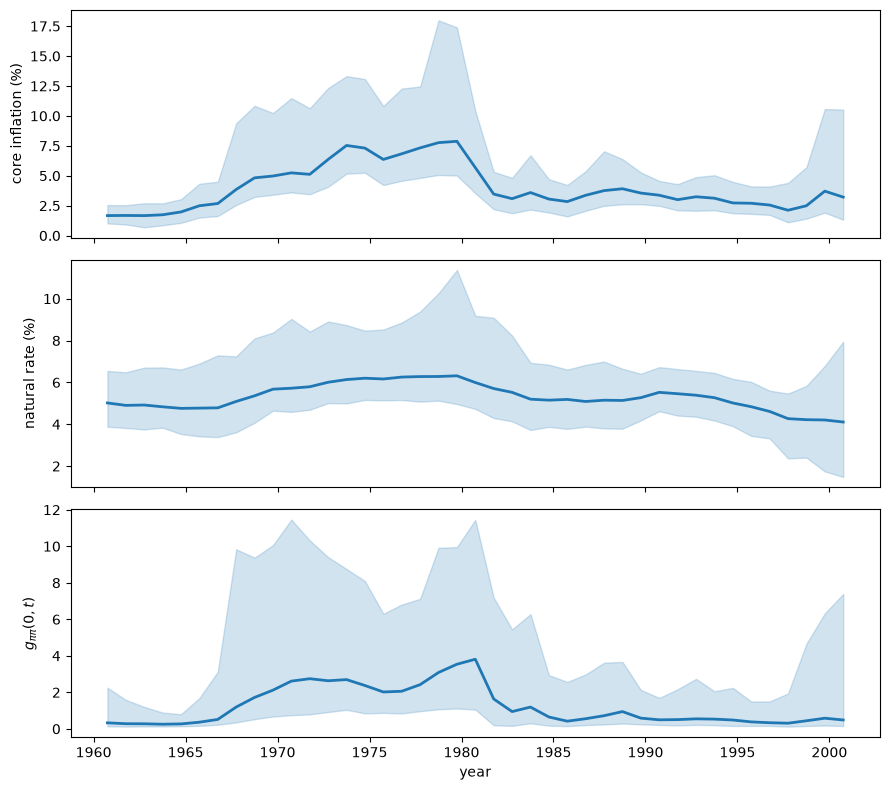

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
feature_specs = (
    ('core', 'core inflation (%)'),
    ('natural', 'natural rate (%)'),
    ('persistence', r'$g_{\pi\pi}(0,t)$'),
)
for ax, (key, ylabel) in zip(axes, feature_specs):
    lower, median, upper = np.quantile(
        historical_feature_draws[key],
        (0.05, 0.5, 0.95),
        axis=1,
    )
    line, = ax.plot(data['dates'][annual], median, lw=2)
    ax.fill_between(
        data['dates'][annual],
        lower,
        upper,
        color=line.get_color(),
        alpha=0.2,
    )
    ax.set_ylabel(ylabel)
axes[-1].set_xlabel('year')
plt.tight_layout()
plt.show()

实线是后验中位数，阴影区域是逐点的90%区间，而非针对整条路径的联合区间。

核心通货膨胀和持续性的中位数路径都保留了先升后于1980年后回落的走势，但它们右偏的区间在整个70年代及1980年前后都明显变宽。

自然失业率的中位数走势更为平滑，其在1980年前后以及样本终点处都存在较大的不确定性，因此历史走势的方向要比其确切幅度更为清晰。

以下这幅图比较了核心通货膨胀和持续性的时间走势。

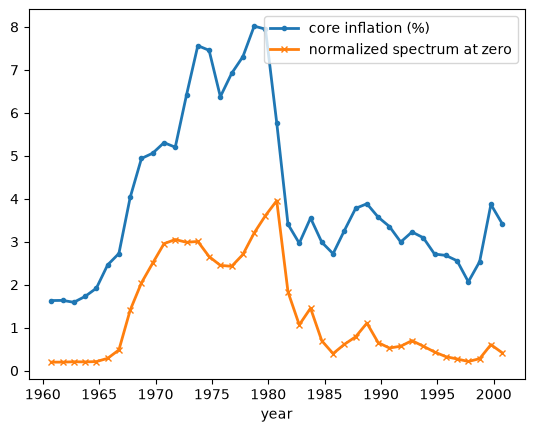

In [32]:
core_persistence_correlation = np.corrcoef(
    core_inflation, inflation_persistence
)[0, 1]

fig, ax = plt.subplots()
ax.plot(data['dates'][annual], 100 * core_inflation[annual], 'o-',
        lw=2, markersize=3, label='core inflation (%)')
ax.plot(data['dates'][annual], inflation_persistence[annual], 'x-',
        lw=2, markersize=4, label='normalized spectrum at zero')
ax.set_xlabel('year')
ax.legend()
plt.show()

核心通货膨胀与归一化持续性在60年代末和70年代同步上升，并在1980年之后几乎同时崩溃，尽管在持续性降至一以下之后，核心通货膨胀仍保持为正值。

它们0.909的季度相关系数总结的是时间上的共性，而非因果关系，因为这两个度量单位不同，且都是同一组拟合系数的非线性总结。

在已拟合的 TVP-VAR 模型内部，这种共同变动支持了系统传播方式的变化以及冲击波动率变化都发挥了重要作用这一观点。

要与固定系数模型进行直接比较，需要拟合受限的 $Q=0$ 模型。

沃尔克反通胀期间持续性的下降，与逃逸路径模型的预测相冲突——在那些模型中，在从高通胀向低通胀过渡的过程中，持续性会不断增加 {cite}`Sargent1999,ChoWilliamsSargent2002`。

这种张力促使后来出现了一些学习模型，在这些模型中，决策者在70年代不愿实施反通胀措施，随后才改弦更张。

### 货币政策的积极程度

科格利和萨金特用一个前瞻性的泰勒规则来总结系统性政策，

```{math}
:label: csdv_policy_rule
i_t = \beta_0
+ \beta_1 \mathbb{E}_t\bar\pi_{t,t+h_\pi}
+ \beta_2 \mathbb{E}_t\bar u_{t,t+h_u}
+ \beta_3 i_{t-1}
+ \nu_t.
```

他们把积极程度系数定义为 $\mathcal A_t=\beta_1/(1-\beta_3)$，并把
$\mathcal A_t\geq 1$ 的情形称为“积极”政策。

在每个日期，局部 VAR 所隐含的总体两阶段最小二乘投影会给出这些政策规则系数。

基准视界为 $h_\pi=4$ 季度和 $h_u=2$ 季度，反映了关于货币政策滞后效应的常规观点。

下面这个函数利用每个局部 VAR 的平稳二阶矩，将短期利率投影到模型所隐含的通货膨胀和失业预测上。

In [33]:
def policy_rule_coefficients(θ, covariance, h_pi=4, h_u=2):
    """Return the local policy-rule coefficients."""
    _, companion = companion_matrix(θ)
    innovation = np.zeros((6, 6))
    innovation[:3, :3] = covariance
    stationary_covariance = linalg.solve_discrete_lyapunov(
        companion, innovation
    )
    selectors = np.eye(6)
    companion_power = np.eye(6)
    inflation_loading = np.zeros(6)
    unemployment_loading = np.zeros(6)
    for horizon in range(1, max(h_pi, h_u) + 1):
        companion_power = companion_power @ companion
        if horizon <= h_pi:
            inflation_loading += selectors[2] @ companion_power
        if horizon <= h_u:
            unemployment_loading += selectors[1] @ companion_power
    inflation_loading /= h_pi
    unemployment_loading /= h_u
    loadings = np.vstack(
        (inflation_loading, unemployment_loading, selectors[0])
    )
    regressor_covariance = loadings @ stationary_covariance @ loadings.T
    cross_covariance = (
        loadings @ stationary_covariance @ companion.T @ selectors[0]
    )
    return np.linalg.solve(regressor_covariance, cross_covariance)


policy_coefficients = np.array(
    [
        policy_rule_coefficients(θ_mean[:, t], r_mean[t])
        for t in range(len(data['dates']))
    ]
)
inflation_response = policy_coefficients[:, 0]
interest_persistence = policy_coefficients[:, 2]
policy_margin = np.where(
    np.abs(interest_persistence) < 1,
    inflation_response + interest_persistence - 1,
    np.nan,
)

对于 $|\beta_3|<1$，政策边际
$\mathcal{M}_t=\beta_{1t}+\beta_{3t}-1$ 恰好在
$\mathcal A_t\geq1$ 时为非负数，并且避免了除以 $1-\beta_3$。

由于 $\beta_3$ 乘以滞后利率，长期反应求和为
$\beta_1(1+\beta_3+\beta_3^2+\cdots)$，这只有在
$|\beta_3|<1$ 时才存在。

图中其余日期留空，因为 $\mathcal A_t$ 在那些日期没有有限的长期解释。

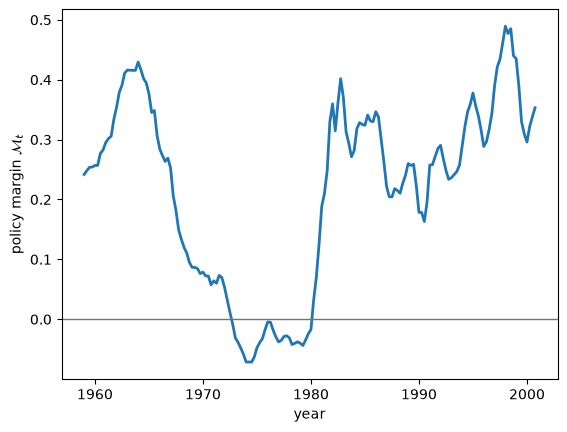

In [34]:
fig, ax = plt.subplots()
ax.plot(data['dates'], policy_margin, lw=2)
ax.axhline(0, color='0.45', lw=1)
ax.set_xlabel('year')
ax.set_ylabel(r'policy margin $\mathcal{M}_t$')
plt.show()

政策边际在70年代的大部分时间里都低于零，然后在80年代初之后果断转为正值。

这一时间点与政策体制对大通胀有所贡献的观点相吻合。

空白区间标记了上述规则忽略了政策边际的那些日期。

以下的散点图使用了第四季度的观测值。

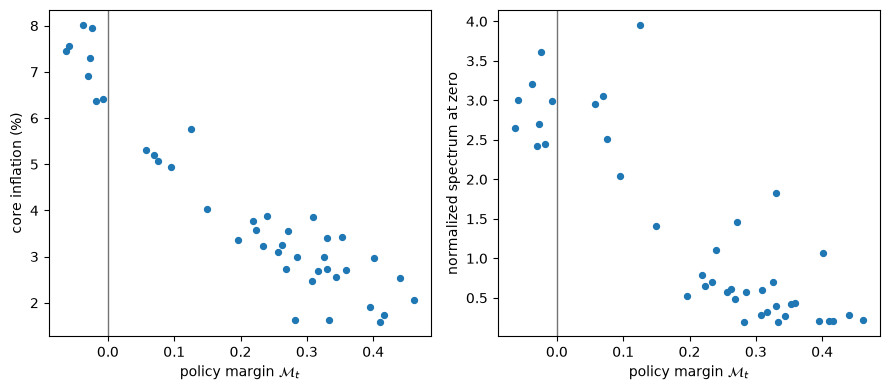

In [35]:
displayed_annual = annual[np.isfinite(policy_margin[annual])]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
pairs = (
    (100 * core_inflation, 'core inflation (%)'),
    (inflation_persistence, 'normalized spectrum at zero'),
)
for ax, (feature, label) in zip(axes, pairs):
    ax.scatter(
        policy_margin[displayed_annual],
        feature[displayed_annual],
        s=18,
    )
    ax.axvline(0, color='0.45', lw=1)
    ax.set_xlabel(r'policy margin $\mathcal{M}_t$')
    ax.set_ylabel(label)
plt.tight_layout()
plt.show()

核心通货膨胀和持续性数值较高的观测点，聚集在零边际附近或以下，而正的政策边际则聚集在这两个度量都取较低值的区域。

所展示的第四季度观测数据表明了一种历史上的关联，而非一种因果性的政策效应。

在某些日期，政策规则系数的识别较弱，因此基于后验均值输入的路径会低估不确定性。

因此，我们从1975年、1985年和1995年的每一个保留抽样中计算积极程度。

In [36]:
selected_years = (1975, 1985, 1995)
selected_dates = [np.flatnonzero(years == year)[-1] for year in selected_years]

activism_draws = {
    year: np.empty(posterior['SD'].shape[2]) for year in selected_years
}
stable_response_by_year = {
    year: np.empty(posterior['SD'].shape[2], dtype=bool)
    for year in selected_years
}
for draw in range(posterior['SD'].shape[2]):
    for year, date in zip(selected_years, selected_dates):
        covariance = innovation_covariance(
            posterior['HD'][date + 1, :, draw],
            posterior['CD'][:, draw],
        )
        rule = policy_rule_coefficients(
            posterior['SD'][:, date, draw], covariance
        )
        activism_draws[year][draw] = rule[0] / (1 - rule[2])
        stable_response_by_year[year][draw] = np.abs(rule[2]) < 1

这些抽样给出了每个日期政策为积极的后验概率，以及在 $|\beta_3|<1$ 的条件下1975年之后积极程度上升的后验概率。

In [37]:
activism_events = (
    activism_draws[1975] > 1,
    activism_draws[1985] > 1,
    activism_draws[1995] > 1,
    activism_draws[1985] > activism_draws[1975],
    activism_draws[1995] > activism_draws[1975],
)
activism_conditions = (
    stable_response_by_year[1975],
    stable_response_by_year[1985],
    stable_response_by_year[1995],
    stable_response_by_year[1985] & stable_response_by_year[1975],
    stable_response_by_year[1995] & stable_response_by_year[1975],
)
assert all(condition.any() for condition in activism_conditions)
activism_probability_values = np.array(
    [
        event[condition].mean()
        for event, condition in zip(activism_events, activism_conditions)
    ]
)

activism_probability_index = (
    'P(A_1975 > 1)',
    'P(A_1985 > 1)',
    'P(A_1995 > 1)',
    'P(A_1985 > A_1975)',
    'P(A_1995 > A_1975)',
)
activism_probabilities = pd.DataFrame(
    {'conditional estimate': activism_probability_values},
    index=activism_probability_index,
)
stable_response_shares = pd.Series(
    {year: draws.mean() for year, draws in stable_response_by_year.items()},
    name='share with |beta_3| < 1',
)

display(activism_probabilities.round(3))
stable_response_shares.to_frame().round(3)

,conditional estimate
P(A_1975 > 1),0.310
P(A_1985 > 1),0.910
P(A_1995 > 1),0.941
P(A_1985 > A_1975),0.912
P(A_1995 > A_1975),0.943


,share with |beta_3| < 1
1975,1.000
1985,0.932
1995,0.980


前三个概率以该日期的 $|\beta_3|<1$ 为条件，而比较则要求两个日期都满足这一条件。

中心抽样分布展示了这些概率估计背后的重叠情况和偏斜程度。

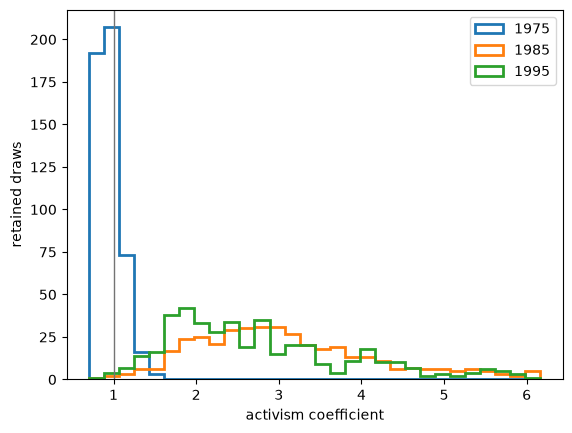

In [38]:
stable_activism_draws = {
    year: activism_draws[year][stable_response_by_year[year]]
    for year in selected_years
}
pooled_activism = np.concatenate(tuple(stable_activism_draws.values()))
activism_limits = np.quantile(pooled_activism, (0.05, 0.95))
activism_bins = np.linspace(*activism_limits, 31)

fig, ax = plt.subplots()
for year in selected_years:
    central_draws = stable_activism_draws[year]
    central_draws = central_draws[
        (central_draws >= activism_limits[0])
        & (central_draws <= activism_limits[1])
    ]
    ax.hist(
        central_draws,
        bins=activism_bins,
        histtype='step',
        lw=2,
        label=str(year),
    )
ax.axvline(1, color='0.45', lw=1)
ax.set_xlabel('activism coefficient')
ax.set_ylabel('retained draws')
ax.legend()
plt.show()

1975年的分布集中在一附近或以下，而1985年和1995年的分布则大幅右移，但仍然较为分散、有所偏斜且相互重叠。

因此后验支持1975年之后从消极政策转为积极政策这一变化，但并不能明确区分1985年与1995年。

图中只绘制了满足 $|\beta_3|<1$ 且位于合并样本第5和第95百分位数之间的抽样，而概率计算则使用了所有满足该条件的抽样。

(csdv-updated-evidence)=
## 又一个四分之一世纪的证据

样本止于2000年第四季度，因此它没有涵盖金融危机、零利率时期、新冠疫情，以及2021至2022年的通货膨胀飙升。

问题在于，这些事件是否会改变此前关于漂移、波动率、通货膨胀持续性和系统性政策的证据。

### 新增的观测数据

为了考察这些事件，我们在2000年第四季度之后附加了最新数据，同时保持2000年第四季度之前的样本不变。

这种拼接方式可以防止将对2001年之前的CPI和失业率数据所做的修订，误认为是新增的四分之一世纪所带来的信息。

我们从 FRED 下载经季节调整的[CPI][fred-cpi]、经季节调整的[失业率][fred-unemployment]，以及[三个月期国库券利率][fred-interest]。

[fred-cpi]: https://fred.stlouisfed.org/series/CPIAUCSL
[fred-unemployment]: https://fred.stlouisfed.org/series/UNRATE
[fred-interest]: https://fred.stlouisfed.org/series/TB3MS

变换方式和季度内的取样时点保持不变：CPI取自第三个月，失业率是三个月的平均值，利率取自第一个月。

In [39]:
fred_url = (
    'https://fred.stlouisfed.org/graph/fredgraph.csv?'
    'id=CPIAUCSL%2CUNRATE%2CTB3MS'
)
fred_monthly = pd.read_csv(
    fred_url,
    parse_dates=['observation_date'],
).set_index('observation_date')


[美国劳工统计局的说明](https://www.bls.gov/web/empsit/cpsee_e12.pdf)指出，由于联邦政府停摆，2025年10月的失业率观测数据未能采集，导致2025年第四季度没有完整的三个月平均值。

因此下面的代码将更新后的样本截止到三个月失业率读数都齐全的最后一个季度，该季度是自动检测出来的，而非硬编码；在撰写本文时，这一季度是2025年第三季度。

In [40]:
def fred_quarterly_table(unemployment_monthly):
    """Construct transformed quarterly observations from current FRED data."""
    interest = fred_monthly.loc[
        fred_monthly.index.month.isin((1, 4, 7, 10)), 'TB3MS'
    ].copy()
    interest.index = interest.index.to_period('Q').start_time

    cpi = fred_monthly.loc[
        fred_monthly.index.month.isin((3, 6, 9, 12)), 'CPIAUCSL'
    ].copy()
    cpi.index = cpi.index.to_period('Q').start_time

    unemployment = unemployment_monthly.resample('QS').mean()
    quarterly = pd.concat(
        {
            'interest': interest,
            'unemployment': unemployment,
            'cpi': cpi,
        },
        axis=1,
    )
    quarterly['y3'] = np.log1p(quarterly['interest'] / 400)
    quarterly['ur'] = quarterly['unemployment'] / 100
    quarterly['dp'] = np.log(quarterly['cpi']).diff()
    quarterly['date'] = (
        quarterly.index.year + (quarterly.index.quarter - 1) / 4
    )
    columns = ['date', 'y3', 'ur', 'dp']
    return quarterly.loc[:, columns].dropna()


unemployment_monthly = fred_monthly['UNRATE']
unemployment_counts = unemployment_monthly.resample('QS').count()
latest_quarterly = fred_quarterly_table(unemployment_monthly)

# Extend the archived sample dynamically: append post-2000Q4 quarters only up
# to the first one missing any of its three monthly unemployment readings, so
# no endpoint is hard-coded.  An isolated missing month -- for example October
# 2025, which the federal shutdown left uncollected -- caps the sample at the
# preceding complete quarter, and a normally incomplete current quarter caps it
# at the last finished one.
quarterly_unfilled = latest_quarterly.loc['2001-01-01':]
month_counts = unemployment_counts.reindex(quarterly_unfilled.index)
incomplete_quarters = month_counts.index[month_counts < 3]
if len(incomplete_quarters):
    first_incomplete_quarter = incomplete_quarters[0]
    complete_extension = quarterly_unfilled.loc[
        quarterly_unfilled.index < first_incomplete_quarter
    ]
else:
    complete_extension = quarterly_unfilled

cs_sample = pd.read_csv(data_url)
overlap_date = pd.Timestamp('2000-10-01')
cs_sample_overlap = cs_sample.iloc[-1]
latest_overlap = latest_quarterly.loc[overlap_date]


def scaled_observation(row):
    """Return observable units for a transformed quarterly row."""
    return pd.Series(
        {
            'interest rate (annual %)': 400 * np.expm1(row['y3']),
            'unemployment (%)': 100 * row['ur'],
            'inflation (annual %)': 400 * row['dp'],
        }
    )


cs_sample_scaled = scaled_observation(cs_sample_overlap)
latest_scaled = scaled_observation(latest_overlap)
splice_audit = pd.DataFrame(
    {
        'Cogley-Sargent (2005) 2000Q4': cs_sample_scaled,
        'latest revised 2000Q4 data': latest_scaled,
        'current minus Cogley-Sargent (2005)': (
            latest_scaled - cs_sample_scaled
        ),
        'first appended 2001Q1': scaled_observation(
            complete_extension.iloc[0]
        ),
    }
)
extended_observations = pd.concat(
    (cs_sample, complete_extension.reset_index(drop=True)),
    ignore_index=True,
)


def quarter_label(timestamp):
    """Format a timestamp as year and quarter."""
    return str(timestamp.to_period('Q'))


display(splice_audit.round(3))

,Cogley-Sargent (2005) 2000Q4,latest revised 2000Q4 data,current minus Cogley-Sargent (2005),first appended 2001Q1
interest rate (annual %),6.253,6.110,-0.143,5.150
unemployment (%),3.967,3.900,-0.067,4.233
inflation (annual %),2.298,2.298,-0.000,3.422


任何缺失值都没有被填补，也没有被当作已观测数据处理。

重叠区间表展示了将存档数据与新下载数据拼接时所产生的任何断点。

新附加的2001年第一季度通货膨胀率对2000年第四季度和2001年第一季度都使用了最新修订后的CPI水平，因此不会有任何一次对数差分是将两个不同数据发布版本的观测值结合起来计算的。

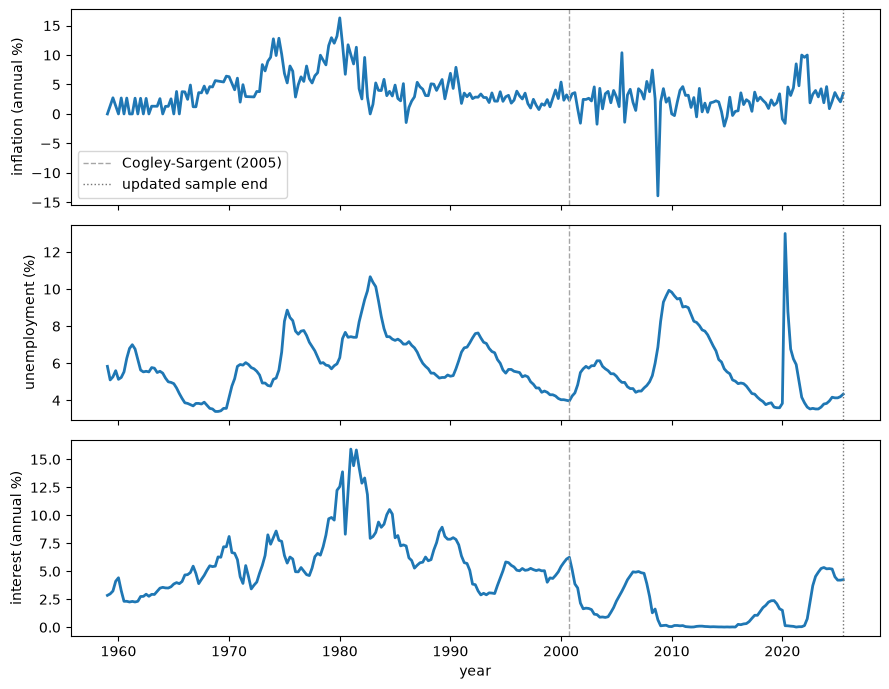

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
extended_plot = extended_observations[
    extended_observations['date'] >= 1959
]
updated_sample_end = complete_extension['date'].iloc[-1]
axes[0].plot(
    extended_plot['date'],
    400 * extended_plot['dp'],
    lw=2,
)
axes[0].set_ylabel('inflation (annual %)')
axes[1].plot(
    extended_plot['date'],
    100 * extended_plot['ur'],
    lw=2,
)
axes[1].set_ylabel('unemployment (%)')
axes[2].plot(
    extended_plot['date'],
    400 * np.expm1(extended_plot['y3']),
    lw=2,
)
axes[2].set_ylabel('interest (annual %)')
axes[2].set_xlabel('year')
for index, ax in enumerate(axes):
    cs_sample_label = 'Cogley-Sargent (2005)' if index == 0 else None
    sample_end_label = 'updated sample end' if index == 0 else None
    ax.axvline(
        2000.75,
        color='0.65',
        ls='--',
        lw=1,
        label=cs_sample_label,
    )
    ax.axvline(
        updated_sample_end,
        color='0.45',
        ls=':',
        lw=1,
        label=sample_end_label,
    )
axes[0].legend()
plt.tight_layout()
plt.show()

In [42]:
endpoint_observation = complete_extension.iloc[-1]
pd.Series(
    {
        'annualized quarterly inflation (%)': (
            400 * endpoint_observation['dp']
        ),
        'unemployment (%)': 100 * endpoint_observation['ur'],
        'three-month interest rate (%)': (
            400 * np.expm1(endpoint_observation['y3'])
        ),
    },
    name=quarter_label(complete_extension.index[-1]),
).to_frame().round(3)

,2025Q3
annualized quarterly inflation (%),3.482
unemployment (%),4.333
three-month interest rate (%),4.250


这次扩展加入了金融危机时期的收缩、疫情期间飙升至13.0%的季度失业率，以及2021—2022年一次短暂的通货膨胀飙升，同时还有两段较长时间的接近零利率时期。

由于通货膨胀是由季度变化年化得到的，孤立的波动在这张图中会显得格外醒目，但最近这次飙升在时间跨度上明显比持续了很长时间的70年代通胀上升要短得多。

这些观测数据对模型是否会将近期的极端情况归因于冲击波动率还是持续性动态，构成了一次严格的检验，而2008年之后接近于零的利率也削弱了短期利率对政策的度量能力。

我们使用上文所述的国库券度量指标，将稳定的 TVP-VAR 模型拟合至2025年第三季度（最后一个完整的季度）。

In [43]:
def append_extension(extension):
    """Append a transformed FRED extension to the Cogley-Sargent sample."""
    extension = extension.reset_index(drop=True)
    table = pd.concat((cs_sample, extension), ignore_index=True)
    assert table['date'].is_unique
    assert np.allclose(np.diff(table['date']), 0.25)
    return table


def fit_updated_model(table):
    """Calibrate and fit the stable drifting VAR to one table."""
    model_data = prepare_data(table)
    model_prior = calibrate_prior(model_data)
    result = run_sampler(
        model_data['y'],
        model_data['x'],
        model_prior,
        n_sweeps=5_000,
        burn=2_500,
        thin=5,
        seed=42,
        warmup=500,
        stable=True,
        progress_every=500,
    )
    validate_posterior_arrays(result, len(model_data['dates']))
    trace = np.trace(result['QD'], axis1=0, axis2=1)
    return {
        'data': model_data,
        'prior': model_prior,
        'posterior': result,
        'trace': trace,
    }


updated_fit = fit_updated_model(append_extension(complete_extension))

latest_data_table = latest_quarterly.loc[
    (latest_quarterly.index >= pd.Timestamp('1948-04-01'))
    & (latest_quarterly.index <= complete_extension.index[-1])
].reset_index(drop=True)
assert np.allclose(np.diff(latest_data_table['date']), 0.25)
latest_data_fit = fit_updated_model(latest_data_table)

500/5,000 sweeps; 907 slice contractions; 0.8 minutes
1,000/5,000 sweeps; 2,157 slice contractions; 1.7 minutes
1,500/5,000 sweeps; 3,239 slice contractions; 2.5 minutes
2,000/5,000 sweeps; 5,002 slice contractions; 3.3 minutes
2,500/5,000 sweeps; 6,186 slice contractions; 4.1 minutes
3,000/5,000 sweeps; 7,163 slice contractions; 4.9 minutes
3,500/5,000 sweeps; 7,943 slice contractions; 5.7 minutes
4,000/5,000 sweeps; 8,577 slice contractions; 6.5 minutes
4,500/5,000 sweeps; 9,404 slice contractions; 7.3 minutes
5,000/5,000 sweeps; 10,158 slice contractions; 8.1 minutes
500/5,000 sweeps; 862 slice contractions; 0.8 minutes
1,000/5,000 sweeps; 2,000 slice contractions; 1.6 minutes
1,500/5,000 sweeps; 3,099 slice contractions; 2.4 minutes
2,000/5,000 sweeps; 4,751 slice contractions; 3.2 minutes
2,500/5,000 sweeps; 6,298 slice contractions; 4.1 minutes
3,000/5,000 sweeps; 7,542 slice contractions; 4.9 minutes
3,500/5,000 sweeps; 8,617 slice contractions; 5.7 minutes
4,000/5,000 sweeps; 9

1,000/5,000 sweeps; 2,157 slice contractions; 1.7 minutes


1,500/5,000 sweeps; 3,239 slice contractions; 2.5 minutes


2,000/5,000 sweeps; 5,002 slice contractions; 3.3 minutes


2,500/5,000 sweeps; 6,186 slice contractions; 4.1 minutes


...

3,000/5,000 sweeps; 7,542 slice contractions; 4.9 minutes


3,500/5,000 sweeps; 8,617 slice contractions; 5.7 minutes


4,000/5,000 sweeps; 9,134 slice contractions; 6.5 minutes


4,500/5,000 sweeps; 9,568 slice contractions; 7.2 minutes


5,000/5,000 sweeps; 10,764 slice contractions; 8.0 minutes


### 系数漂移是否持续？

In [44]:
def updated_drift_summary(fit):
    """Summarize the updated coefficient-drift distribution."""
    trace = fit['trace']
    q_mean = fit['posterior']['QD'].mean(axis=2)
    eigenvalues = np.linalg.eigvalsh(q_mean)[::-1]
    return {
        'posterior mean tr(Q)': trace.mean(),
        'share in first three eigen-directions': (
            eigenvalues[:3].sum() / eigenvalues.sum()
        ),
    }


updated_label = quarter_label(complete_extension.index[-1])
updated_summary = pd.DataFrame(
    {
        'Cogley-Sargent (2005) + extension': (
            updated_drift_summary(updated_fit)
        ),
        'latest revised data for full sample': updated_drift_summary(
            latest_data_fit
        ),
    }
)
updated_summary.round(3)

,Cogley-Sargent (2005) + extension,latest revised data for full sample
posterior mean tr(Q),0.073,0.034
share in first three eigen-directions,0.976,0.955


漂移速率分布和系数路径提供了与 {cite:t}`CogleySargent2005` 样本相同的视角。

更新后的时间序列图中的竖直虚线标记了 {cite:t}`CogleySargent2005` 样本2000年第四季度的终点，但每一条更新后的路径都来自一次完整的重新估计，而不是把新的点附加到未发生变化的历史估计之上。

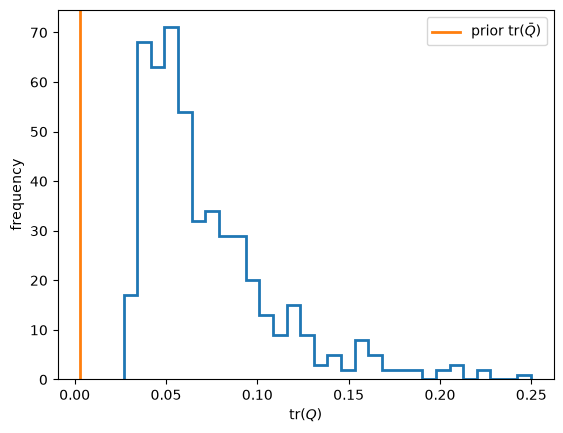

In [45]:
fig, ax = plt.subplots()
ax.hist(updated_fit['trace'], bins=30, histtype='step', lw=2)
ax.axvline(
    np.trace(updated_fit['prior']['q_center']),
    color='C1',
    lw=2,
    label=r'prior $\mathrm{tr}(\bar Q)$',
)
ax.set_xlabel(r'$\mathrm{tr}(Q)$')
ax.set_ylabel('frequency')
ax.legend()
plt.show()

在两种数据构造方式下，全样本的后验漂移速率都仍然高于其保守的先验校准值。

在 TVP-VAR 模型内部，这表明存在不可忽略的全样本漂移，但这并不是对 $Q=0$ 与 $Q>0$ 的一次正式比较。

其大小取决于历史观测值是来自存档数据集，还是来自最新的修订数据。

由于 $Q$ 是针对整个1959—2025年路径的单一方差参数，这一直方图本身并不能表明漂移在2000年之后加速了。

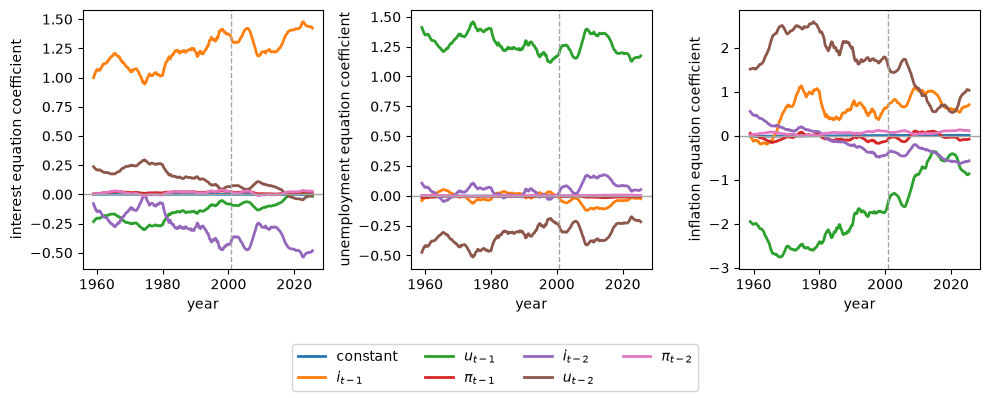

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharex=True)
updated_dates = updated_fit['data']['dates']
updated_coefficients = updated_fit['posterior']['SD'].mean(axis=2)
coefficient_lines = plot_equation_coefficients(
    axes,
    updated_dates,
    updated_coefficients,
)
for ax in axes:
    ax.axvline(2000.75, color='0.65', ls='--', lw=1)
fig.legend(
    coefficient_lines,
    coefficient_labels,
    loc='lower center',
    ncol=4,
)
plt.tight_layout(rect=(0, 0.17, 1, 1))
plt.show()

若干系数路径在2000年之后仍然在缓慢地移动，其中最大的变化再次集中在通货膨胀方程中，而不是表现为突然的金融危机或疫情式的断点。

某些成对滞后系数彼此相反的变动，也说明了为何它们的综合动态含义比任何单条曲线都更具信息量。

前三个特征方向占据了后验均值漂移方差的大多数，因此所估计的变动仍然是低维的。

如今稳定性限制作用于一条更长的路径，这使得后验漂移速率成为整个1959—2025年样本的一个特性。

### 大缓和之后的波动率

接下来我们要把创新的大小和相关性变化，与 VAR 动态的变化区分开来。

In [47]:
def model_features(fit):
    """Compute features at posterior mean parameters."""
    result = fit['posterior']
    θ = result['SD'].mean(axis=2)
    mean_root_modulus = np.max(
        np.abs(companion_roots(θ)), axis=1
    )
    if not np.all(mean_root_modulus < 1):
        raise ValueError('mean coefficient path is unstable')
    covariance = mean_innovation_covariance(result['HD'], result['CD'])
    core, natural = local_means(θ)
    persistence = np.array([
        inflation_spectrum(
            θ[:, t], covariance[t], zero_frequency
        )[1][0]
        for t in range(len(fit['data']['dates']))
    ])
    sign, logdet = np.linalg.slogdet(covariance)
    assert np.all(sign > 0)
    policy_coefficients = np.array(
        [
            policy_rule_coefficients(θ[:, t], covariance[t])
            for t in range(len(fit['data']['dates']))
        ]
    )
    inflation_response = policy_coefficients[:, 0]
    interest_persistence = policy_coefficients[:, 2]
    policy_margin = np.where(
        np.abs(interest_persistence) < 1,
        inflation_response + interest_persistence - 1,
        np.nan,
    )
    return {
        'θ': θ,
        'maximum_companion_root': mean_root_modulus.max(),
        'covariance': covariance,
        'core': core,
        'natural': natural,
        'persistence': persistence,
        'logdet': logdet,
        'policy_margin': policy_margin,
    }


updated_features = model_features(updated_fit)
latest_data_features = model_features(latest_data_fit)

pd.Series(
    {
        'Cogley-Sargent (2005) + extension': (
            updated_features['maximum_companion_root']
        ),
        'latest revised data for full sample': (
            latest_data_features['maximum_companion_root']
        ),
    },
    name='maximum companion-root modulus of mean path',
).to_frame().round(4)

,maximum companion-root modulus of mean path
Cogley-Sargent (2005) + extension,0.9569
latest revised data for full sample,0.9613


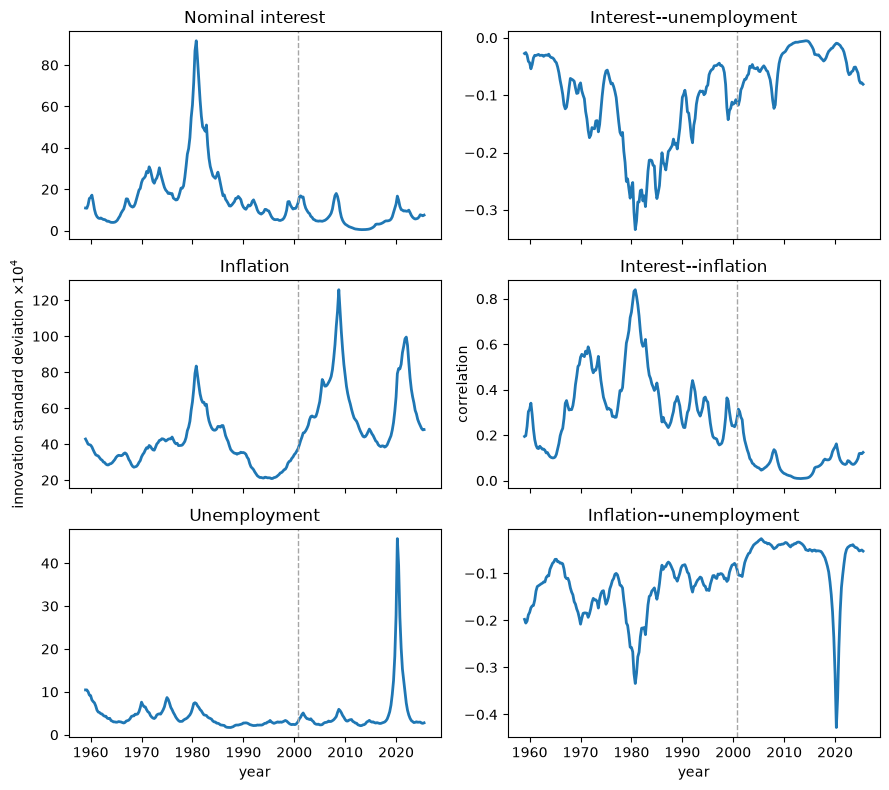

In [48]:
fig, axes = plt.subplots(3, 2, figsize=(9, 8), sharex=True)
dates = updated_fit['data']['dates']
covariance = updated_features['covariance']
for row, (index, _) in enumerate(variances):
    axes[row, 0].plot(
        dates,
        10000 * np.sqrt(covariance[:, index, index]),
        lw=2,
    )
for row, (left, right, _) in enumerate(correlations):
    scale = np.sqrt(
        covariance[:, left, left] * covariance[:, right, right]
    )
    axes[row, 1].plot(
        dates,
        covariance[:, left, right] / scale,
        lw=2,
    )
for row, (_, label) in enumerate(variances):
    axes[row, 0].set_title(label)
for row, (_, _, label) in enumerate(correlations):
    axes[row, 1].set_title(label)
for ax in axes.flat:
    ax.axvline(2000.75, color='0.65', ls='--', lw=1)
axes[1, 0].set_ylabel(
    r'innovation standard deviation $\times 10^4$'
)
axes[1, 1].set_ylabel('correlation')
axes[-1, 0].set_xlabel('year')
axes[-1, 1].set_xlabel('year')
plt.tight_layout()
plt.show()

沃尔克转型时期在利率创新波动率中依然占据主导地位，金融危机导致了最大的通货膨胀波动率峰值，而疫情则在失业创新波动率上独占鳌头。

疫情还导致通货膨胀与失业率之间的相关系数急剧下降，因此近期事件既改变了简化形式冲击的构成，也改变了它们的大小。

这是关于运气不好这一成分的直接证据，尽管简化形式的创新并不能证明这些潜在扰动在结构上是外生的。

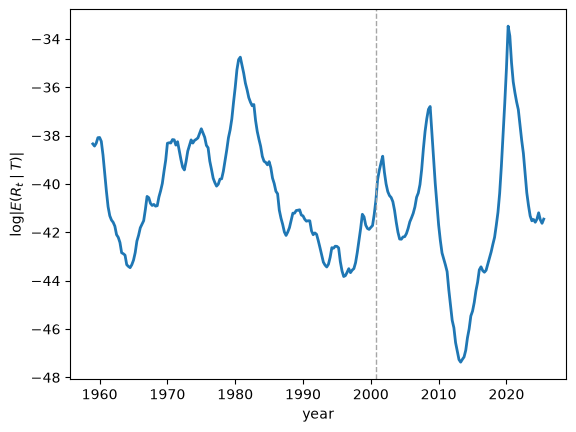

In [49]:
fig, ax = plt.subplots()
ax.plot(
    updated_fit['data']['dates'],
    updated_features['logdet'],
    lw=2,
)
ax.axvline(2000.75, color='0.65', ls='--', lw=1)
ax.set_xlabel('year')
ax.set_ylabel(r'$\log |E(R_t\mid T)|$')
plt.show()

联合创新方差在金融危机期间上升，在2010年代达到大缓和时期的一个深谷，然后在2020年跃升至甚至超过1981年峰值的水平，随后又迅速下降。

In [50]:
def decimal_quarter_label(value):
    """Format a decimal quarterly date."""
    year = int(np.floor(value + 1e-8))
    quarter = int(round(4 * (value - year))) + 1
    return f'{year}Q{quarter}'


def volatility_summary(fit, features):
    """Summarize innovation-volatility peaks and endpoints."""
    dates = fit['data']['dates']
    standard_deviation = 10000 * np.sqrt(
        np.diagonal(features['covariance'], axis1=1, axis2=2)
    )
    names = ('interest', 'unemployment', 'inflation')
    return pd.DataFrame(
        {
            'peak quarter': [
                decimal_quarter_label(
                    dates[np.argmax(standard_deviation[:, index])]
                )
                for index in range(n_variables)
            ],
        },
        index=names,
    )


updated_volatility = volatility_summary(updated_fit, updated_features)
updated_volatility

,peak quarter
interest,1980Q4
unemployment,2020Q2
inflation,2008Q4


在2025年第三季度这一终点，三种创新标准差都远低于各自的峰值，这在该模型内部支持了疫情冲击是一个大而短暂的事件这一解释。

### 2000年之后的核心通货膨胀与自然失业率

同样的局部均值计算能够区分暂时性的通货膨胀与模型长期预测的转变。

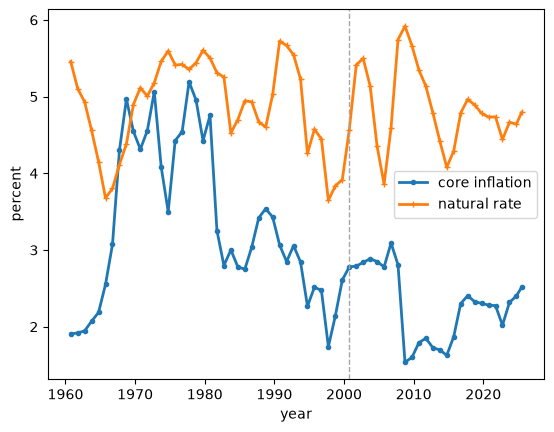

In [51]:
updated_dates = updated_fit['data']['dates']
updated_annual = annual_indices(updated_dates)
fig, ax = plt.subplots()
ax.plot(
    updated_dates[updated_annual],
    100 * updated_features['core'][updated_annual],
    'o-',
    lw=2,
    markersize=3,
    label='core inflation',
)
ax.plot(
    updated_dates[updated_annual],
    100 * updated_features['natural'][updated_annual],
    '+-',
    lw=2,
    markersize=5,
    label='natural rate',
)
ax.axvline(2000.75, color='0.65', ls='--', lw=1)
ax.set_xlabel('year')
ax.set_ylabel('percent')
ax.legend()
plt.show()

这里70年代核心通货膨胀的峰值低于 {cite:t}`CogleySargent2005` 图中所显示的水平，因为后来的观测数据修正了平滑后的历史值，所以竖直虚线两侧的数值都属于同一次更新后的拟合结果。

2000年之后，核心通货膨胀率大多维持在约2%到3%之间，即使2020年之后观测到的通货膨胀率大幅上升，核心通货膨胀率也只是温和上升。

自然失业率曲线是模型局部隐含的长期失业率锚点，这正是为何2020年季度失业率能跳升至13.0%，而这条曲线却依然保持在接近5%的水平的原因。

月度峰值为14.8%。

由于样本在第四季度之前结束，最后一个年度点代表的是2025年第三季度。

In [52]:
def endpoint_features(features):
    """Return economically scaled endpoint features."""
    return pd.Series(
        {
            'core inflation (%)': 100 * features['core'][-1],
            'natural rate (%)': 100 * features['natural'][-1],
            'normalized persistence': features['persistence'][-1],
            'log generalized innovation variance': features['logdet'][-1],
        }
    )


updated_endpoints = endpoint_features(updated_features).to_frame(
    name=updated_label
).T
latest_data_endpoints = endpoint_features(
    latest_data_features
).to_frame(name=updated_label).T
data_revision_sensitivity = pd.concat(
    {
        'Cogley-Sargent (2005) + extension': updated_endpoints,
        'latest revised data for full sample': latest_data_endpoints,
    }
)
data_revision_sensitivity.round(3)

,,core inflation (%),natural rate (%),normalized persistence,log generalized innovation variance
Cogley-Sargent (2005) + extension,2025Q3,2.514,4.794,0.304,-41.454
latest revised data for full sample,2025Q3,2.387,4.539,0.250,-41.075


终点处的核心通货膨胀、自然失业率和持续性总结在这两种数据构造方式下都相似。

按抽样计算的年度路径展示了不确定性在更新后的拟合结果内部是如何演变的。

In [53]:
updated_feature_draws = posterior_feature_draws(
    updated_fit['posterior'],
    updated_annual,
)

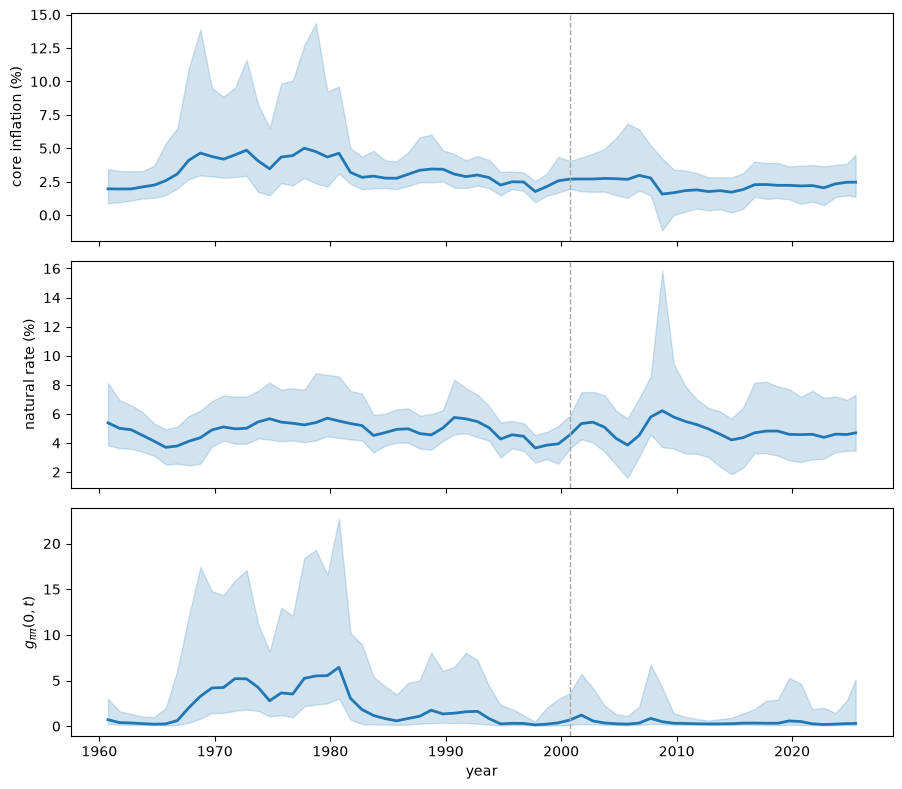

In [54]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for ax, (key, ylabel) in zip(axes, feature_specs):
    lower, median, upper = np.quantile(
        updated_feature_draws[key],
        (0.05, 0.5, 0.95),
        axis=1,
    )
    line, = ax.plot(updated_dates[updated_annual], median, lw=2)
    ax.fill_between(
        updated_dates[updated_annual],
        lower,
        upper,
        color=line.get_color(),
        alpha=0.2,
    )
    ax.axvline(2000.75, color='0.65', ls='--', lw=1)
    ax.set_ylabel(ylabel)
axes[-1].set_xlabel('year')
plt.tight_layout()
plt.show()

实线是后验中位数，阴影区域是逐点的90%区间，而非针对整条路径的联合区间。

2000年之后，核心通货膨胀中位数相对平坦，持续性中位数也保持在较低水平，而自然失业率区间较宽，并在终点处再次变宽。

终点处的行总结了这三个非线性特征的不确定性。

In [55]:
def endpoint_feature_intervals(draws):
    """Summarize draw-wise uncertainty in endpoint model features."""
    labels = {
        'core': 'core inflation (%)',
        'natural': 'natural rate (%)',
        'persistence': 'normalized persistence',
    }
    rows = {}
    for key, label in labels.items():
        values = draws[key][-1]
        rows[label] = {
            'median': np.median(values),
            '5th percentile': np.quantile(values, 0.05),
            '95th percentile': np.quantile(values, 0.95),
        }
    return pd.DataFrame.from_dict(rows, orient='index')


updated_endpoint_intervals = endpoint_feature_intervals(
    updated_feature_draws
)
updated_endpoint_intervals.round(3)

,median,5th percentile,95th percentile
core inflation (%),2.463,1.383,4.529
natural rate (%),4.698,3.470,7.302
normalized persistence,0.301,0.107,5.102


正如上表所示，在2025年第三季度，核心通货膨胀和自然失业率的中位数都仍处于历史上较为温和的水平。

它们的区间依然较宽，归一化持续性也仍保留着相当大的上尾，因此将近期的通货膨胀归类为暂时性现象这一结论并非确定无疑。

### 通货膨胀是否再次变得持久？

这里的持续性指的是通货膨胀创新向未来通货膨胀的传播程度，而不是观测到的通货膨胀保持高位的季度数量。

归一化谱降低了对冲击规模共同变化的敏感度，尽管它仍然依赖于 $R_t$ 中的相对方差和协方差。

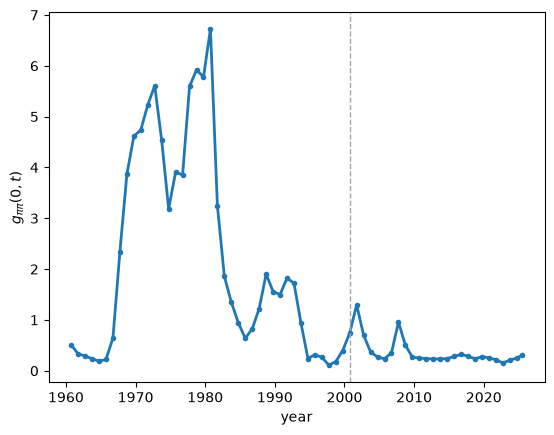

In [56]:
fig, ax = plt.subplots()
ax.plot(
    updated_dates[updated_annual],
    updated_features['persistence'][updated_annual],
    'o-',
    lw=2,
    markersize=3,
)
ax.axvline(2000.75, color='0.65', ls='--', lw=1)
ax.set_xlabel('year')
ax.set_ylabel(r'$g_{\pi\pi}(0,t)$')
plt.show()

估计出的 $g_{\pi\pi}(0,t)$ 路径重现了上升到1980年峰值再随后崩溃的走势，但2000年之后它一直停留在约0.2到0.5之间，且在2020年之后只是略有上升。

一连串较大的简化形式创新可以使观测到的通货膨胀在数个季度内保持高位，而不必产生70年代所估计出的那种强烈传播效应。

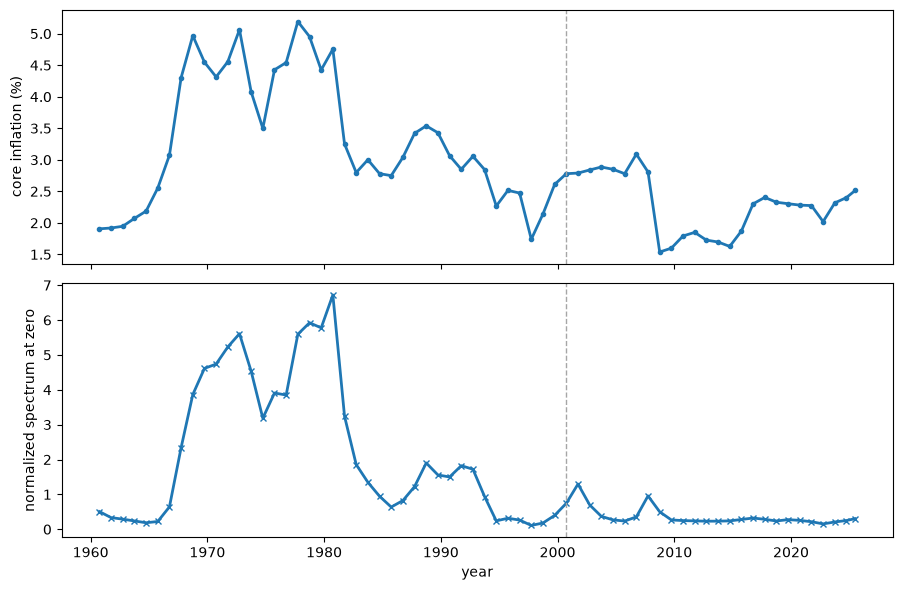

In [57]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 6),
    sharex=True,
)
axes[0].plot(
    updated_dates[updated_annual],
    100 * updated_features['core'][updated_annual],
    'o-',
    lw=2,
    markersize=3,
)
axes[1].plot(
    updated_dates[updated_annual],
    updated_features['persistence'][updated_annual],
    'x-',
    lw=2,
    markersize=4,
)
for ax in axes:
    ax.axvline(2000.75, color='0.65', ls='--', lw=1)
axes[0].set_ylabel('core inflation (%)')
axes[1].set_ylabel('normalized spectrum at zero')
axes[1].set_xlabel('year')
plt.tight_layout()
plt.show()

核心通货膨胀从2010年代中期的低点恢复至接近其早前水平，而持续性则仍停留在1980年后的低位区间，并未随之上升。

这种分歧将模型长期通货膨胀率的温和上升，与向70年代式传播模式的回归区分开来。

完整的谱图展示了这种差异的来源。

In [58]:
updated_raw_spectrum, updated_normalized_spectrum = (
    inflation_spectrum_surface(
        updated_features['θ'],
        updated_features['covariance'],
        spectrum_frequencies,
    )
)

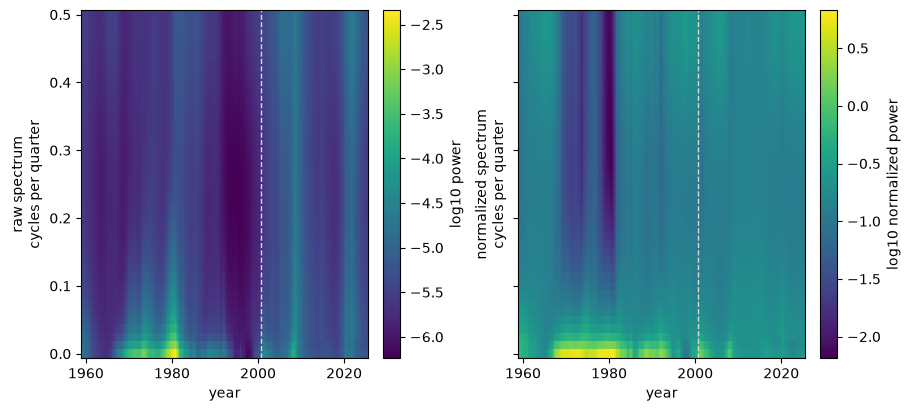

In [59]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4),
    sharey=True,
    constrained_layout=True,
)
updated_surfaces = (
    (updated_raw_spectrum, 'raw spectrum', 'log10 power'),
    (
        updated_normalized_spectrum,
        'normalized spectrum',
        'log10 normalized power',
    ),
)
for ax, (surface, title, color_label) in zip(axes, updated_surfaces):
    image = ax.pcolormesh(
        updated_dates,
        spectrum_frequencies,
        np.log10(surface),
        shading='auto',
    )
    ax.axvline(2000.75, color='0.85', ls='--', lw=1)
    ax.set_xlabel('year')
    ax.set_ylabel(f'{title}\ncycles per quarter')
    fig.colorbar(image, ax=ax, label=color_label)
plt.show()

金融危机和疫情在 $f_{\pi\pi}(\omega,t)$ 中表现为明亮而宽阔的条带，因为简化形式的创新方差增大了。

归一化谱 $g_{\pi\pi}(\omega,t)$ 在2000年之后并不存在与70年代相当的低频“脊”。

综合来看，这些图不支持出现向70年代式持续性回归的观点，同时也没有使这一归一化统计量脱离对 $R_t$ 的依赖。

In [60]:
def episode_summary(fit, features):
    """Average selected features over economically distinct episodes."""
    years = np.floor(fit['data']['dates'] + 1e-8).astype(int)
    periods = {
        '1970--1979': (years >= 1970) & (years <= 1979),
        '1985--2000': (years >= 1985) & (years <= 2000),
        '2001--2019': (years >= 2001) & (years <= 2019),
        '2020--2022': (years >= 2020) & (years <= 2022),
        '2023--2025Q3': years >= 2023,
    }
    rows = {}
    for label, mask in periods.items():
        rows[label] = {
            'core inflation (%)': 100 * features['core'][mask].mean(),
            'normalized persistence': features['persistence'][mask].mean(),
            'log generalized innovation variance': (
                features['logdet'][mask].mean()
            ),
        }
    return pd.DataFrame.from_dict(rows, orient='index')


updated_episodes = episode_summary(updated_fit, updated_features)
updated_episodes.round(3)

,core inflation (%),normalized persistence,log generalized innovation variance
1970--1979,4.518,4.756,-38.614
1985--2000,2.786,0.914,-42.006
2001--2019,2.293,0.414,-42.099
2020--2022,2.226,0.229,-36.432
2023--2025Q3,2.343,0.228,-41.306


各阶段的平均值对比了2020—2022年的高波动率与2000年之后各十年间较低的归一化持续性。

### 近期的政策积极程度能否被度量？

当 $|\beta_3|<1$ 时，政策边际给出了与2000年之后相同的积极政策分类，而无需除以 $1-\beta_3$。

在以下图中，灰色线标记了积极政策的阈值 $\mathcal{M}_t=0$。

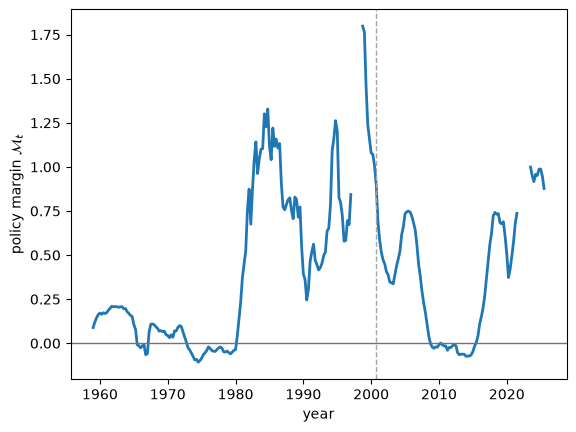

In [61]:
fig, ax = plt.subplots()
updated_policy_margin = updated_features['policy_margin']
ax.plot(updated_dates, updated_policy_margin, lw=2)
ax.axhline(0, color='0.45', lw=1)
ax.axvline(2000.75, color='0.65', ls='--', lw=1)
ax.set_xlabel('year')
ax.set_ylabel(r'policy margin $\mathcal{M}_t$')
plt.show()

在所展示的2000年之后的日期中，政策边际大多为正，并在2010年代中期以及2020年前后移向零。

空白区间省略了拟合出的利率反应无法稳定收敛的那些日期。

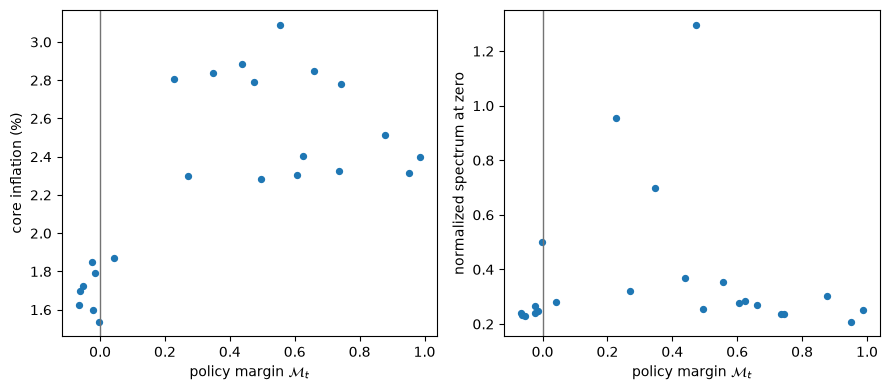

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
recent_annual = annual_indices(updated_dates, start=2001)
displayed_recent = recent_annual[
    np.isfinite(updated_policy_margin[recent_annual])
]
axes[0].scatter(
    updated_policy_margin[displayed_recent],
    100 * updated_features['core'][displayed_recent],
    s=18,
)
axes[1].scatter(
    updated_policy_margin[displayed_recent],
    updated_features['persistence'][displayed_recent],
    s=18,
)
for ax in axes:
    ax.axvline(0, color='0.45', lw=1)
    ax.set_xlabel(r'policy margin $\mathcal{M}_t$')
axes[0].set_ylabel('core inflation (%)')
axes[1].set_ylabel('normalized spectrum at zero')
plt.tight_layout()
plt.show()

其余2000年之后的观测数据并不能在政策边际、核心通货膨胀和持续性之间确立一种稳定的因果关系。

我们还考察了2025年第三季度终点处的中心抽样分布。

In [63]:
def endpoint_policy_margin_draws(fit):
    """Return endpoint margins and stability indicators."""
    result = fit['posterior']
    margins = np.empty(result['SD'].shape[2])
    stable_response = np.empty(result['SD'].shape[2], dtype=bool)
    for draw in range(len(margins)):
        covariance = innovation_covariance(
            result['HD'][-1, :, draw],
            result['CD'][:, draw],
        )
        rule = policy_rule_coefficients(
            result['SD'][:, -1, draw], covariance
        )
        margins[draw] = rule[0] + rule[2] - 1
        stable_response[draw] = np.abs(rule[2]) < 1
    return margins, stable_response


updated_margin_draws, stable_response_draws = (
    endpoint_policy_margin_draws(updated_fit)
)
assert np.any(stable_response_draws)
stable_margin_draws = updated_margin_draws[stable_response_draws]
updated_margin_summary = pd.Series(
    {
        'median M': np.median(stable_margin_draws),
        '5th percentile of M': np.quantile(stable_margin_draws, 0.05),
        '95th percentile of M': np.quantile(stable_margin_draws, 0.95),
        'P(M >= 0 | |beta_3| < 1)': np.mean(stable_margin_draws >= 0),
        'share with |beta_3| < 1': stable_response_draws.mean(),
    },
    name=updated_label,
).to_frame().T
updated_margin_summary.round(3)

,median M,5th percentile of M,95th percentile of M,P(M >= 0 | |beta_3| < 1),share with |beta_3| < 1
2025Q3,0.383,-0.643,1.121,0.904,0.732


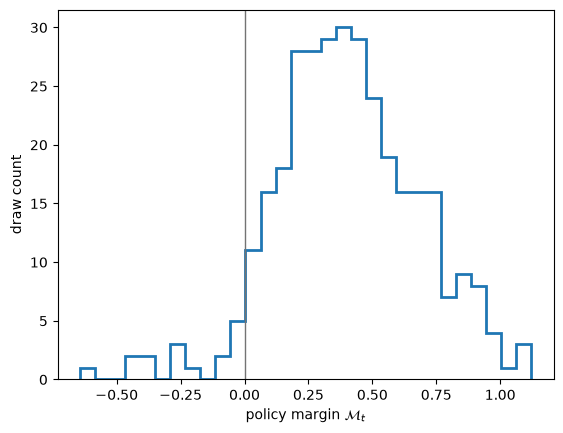

In [64]:
updated_margin_limits = np.quantile(
    stable_margin_draws,
    (0.05, 0.95),
)
updated_margin_bins = np.linspace(*updated_margin_limits, 31)

fig, ax = plt.subplots()
central_draws = stable_margin_draws[
    (stable_margin_draws >= updated_margin_limits[0])
    & (stable_margin_draws <= updated_margin_limits[1])
]
ax.hist(
    central_draws,
    bins=updated_margin_bins,
    histtype='step',
    lw=2,
)
ax.axvline(0, color='0.45', lw=1)
ax.set_xlabel(r'policy margin $\mathcal{M}_t$')
ax.set_ylabel('draw count')
plt.show()

表中报告了具有稳定利率反应的抽样比例，以及在这些抽样中积极政策的概率。

若某一区间跨越零点，则表明终点处的分类仍存在不确定性。

图中只显示了处于第5和第95百分位数之间的抽样，而零利率下限和非常规政策进一步削弱了2008年之后这一短期利率投影的解释力。

### 新增观测数据改变了什么

这额外的四分之一世纪增加了一次戏剧性的波动率事件，但没有出现与70年代相当的2000年后低频“脊”。

疫情是主导性的总体不确定性事件，但近期的通货膨胀飙升并未重现70年代那种低频持续性“脊”。

在更新后的 TVP-VAR 模型内部，全样本漂移速率的后验分布依然高于其保守的先验校准值；要进行固定系数比较，需要一个单独的 $Q=0$ 模型。

2025年第三季度的自然失业率和政策边际估计仍不够精确，尤其是因为并非每一次后验抽样都满足 $|\beta_3|<1$。

(csdv-verdict)=
## 政策不当还是运气不好？一个结论

贝叶斯 VAR 模型对本讲座开篇提出的问题给出了一个细致入微的答案。

- *波动率发生了漂移：* 冲击的大小发生了巨大的变化，出现了沃尔克时期的一次飙升以及随后的大缓和，因此运气不好的说法确实抓住了某些真实的东西。

- *已拟合的 TVP-VAR 也将变动归因于系数：* 通货膨胀持续性和核心通货膨胀在整个70年代上升，并在80年代下降，尽管一个正式的固定系数与漂移系数模型的比较需要一个单独的 $Q=0$ 模型。

- *新增的观测数据并未推翻这一区分：* 疫情产生了一次极端的波动率事件，而近期的通货膨胀飙升并未重现70年代的持续性。

简化形式的 VAR 本身无法证明是美联储信念的变化导致了系数漂移，因为私人部门行为和其他未被纳入模型的机制同样能够改变简化形式的动态。

还有一个转折，它把我们带回到本节的理论。

{doc}`phillips_learning` 和
{doc}`phillips_escaping_nash` 中的逃逸路径模型预测，随着一个学习型政府愈发不愿放弃一个高通胀的自我实现均衡，通货膨胀持续性应当在反通胀过程中*上升*。

数据却显示出相反的情况，因为1980年之后随着通货膨胀下降，持续性也随之下降。

这促成了后来的一些学习模型，包括 {cite:t}`CogleySargentConquest2005` 和 {cite:t}`Primiceri2006`，在这些模型中，决策者在70年代不愿实施反通胀措施、以及他们最终的转变，共同产生了一种先上升后下降的持续性。

与西姆斯、扎、伯南克和米霍夫的这场友好辩论，因此所做的远不止裁决一个历史问题。

它使贯穿本节的学习与漂移理论模型更为精细——从《征服》一书中的 {doc}`自我实现均衡 <phillips_self_confirming>`，到用于解读后来通货膨胀的 {doc}`漂移的美联储信念 <phillips_lost_conquest>`。

## 练习

```{exercise}
:label: csdv_ex1

对于一个 $AR(1)$ 过程，归一化的零频率功率为

$$
g(0)=\frac{1+\rho}{2\pi(1-\rho)}.
$$

计算 $\rho=0$、$0.85$ 和 $0.97$ 时的 $g(0)$，并使用上文的持续性路径，解释1980年前后通货膨胀动态是如何变化的。
```

```{solution-start} csdv_ex1
:class: dropdown
```

In [65]:
ρ = np.array([0.0, 0.85, 0.97])
g0 = (1 + ρ) / (2 * np.pi * (1 - ρ))
pd.Series(g0, index=ρ, name='normalized power at zero').to_frame()

,normalized power at zero
0.00,0.159155
0.85,1.962911
0.97,10.451175


白噪声的 $g(0)=1/(2\pi)$，而大约在2到10之间的取值，则对应于系数在约
$0.85$ 到 $0.97$ 之间的高度持续性自回归过程。

因此，大通胀期间零频率功率的上升以及1980年之后的下降，代表着持续性发生了巨大变化。

```{solution-end}
```

```{exercise}
:label: csdv_ex2

在本讲座中，我们始终强调，要对漂移系数与恒定系数进行正式的比较，需要用 $Q=0$（即纯粹的“运气不好”的特殊情形，其中 VAR 系数被冻结，只有随机波动率 $H_t$ 变动）重新拟合模型。

该抽样器已经支持这一点：向 `run_sampler` 传入
`fixed_q=np.zeros((n_coefficients, n_coefficients))`，即可将 $Q$ 固定为零，而不是对其进行抽样。

将这个恒定系数模型拟合到科格利—萨金特样本，并将其归一化零频率谱
$g_{\pi\pi}(0,t)$ 与 {numref}`fig-csdv-inflation-persistence` 中的漂移系数路径进行对比。

在所度量的持续性中，70年代的上升与1980年后的下降会发生什么变化？这告诉了你什么关于仅靠漂移*波动率*是否能够解释持续性动态的信息？
```

```{solution-start} csdv_ex2
:class: dropdown
```

在 $Q=0$ 的情形下，椭圆切片更新所返回的系数路径在整个时间上保持恒定，因此 $A_{t\mid T}$ 不再变动，而
$g_{\pi\pi}(0,t)$ 中随时间变化的唯一剩余来源，就是漂移中的协方差 $R_t$。

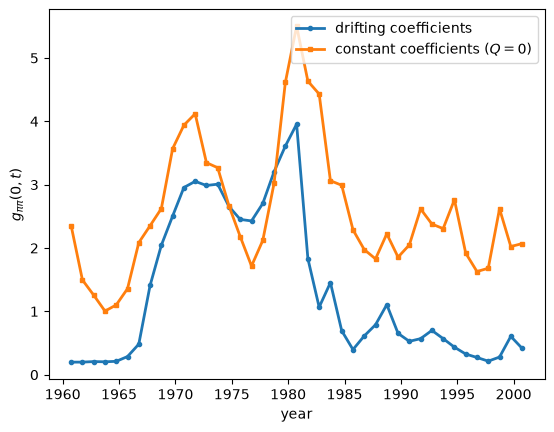

In [66]:
constant_posterior = run_sampler(
    data['y'],
    data['x'],
    prior,
    n_sweeps=1_000,
    burn=500,
    thin=1,
    seed=42,
    warmup=200,
    stable=True,
    fixed_q=np.zeros((n_coefficients, n_coefficients)),
)

constant_θ = constant_posterior['SD'].mean(axis=2)
constant_R = mean_innovation_covariance(
    constant_posterior['HD'], constant_posterior['CD']
)
constant_persistence = np.array([
    inflation_spectrum(constant_θ[:, t], constant_R[t], zero_frequency)[1][0]
    for t in range(len(data['dates']))
])

fig, ax = plt.subplots()
ax.plot(data['dates'][annual], inflation_persistence[annual], 'o-',
        lw=2, markersize=3, label='drifting coefficients')
ax.plot(data['dates'][annual], constant_persistence[annual], 's-',
        lw=2, markersize=3, label=r'constant coefficients ($Q=0$)')
ax.set_xlabel('year')
ax.set_ylabel(r'$g_{\pi\pi}(0,t)$')
ax.legend()
plt.show()

即使 $A$ 固定不变，持续性度量仍会变动，因为 $R_t$ 的*构成*——即三个正交冲击的相对大小——即便在其总体尺度被归一化去除之后，依然会发生变化。

事实上，恒定系数路径同样在1980年前后攀升至一个峰值，因为通货膨胀创新相对于其他创新变得更大，因此单凭运气不好这一渠道，就能够制造出*上升*阶段的大部分现象。

它无法重现的是*下降*阶段：1980年之后，恒定系数模型下的持续性在样本剩余时间里一直维持在2到3左右的高位，而漂移系数路径则崩溃回落到一以下。

将 $A$ 冻结在其全样本平均值上，会使得通货膨胀在90年代的传播强度几乎与70年代相当。

因此，仅靠漂移的波动率能够解释一部分上升过程，但完全不能解释沃尔克时期持续性的反通胀式下降——1980年之后的这次崩溃，正是关于*系统性*动态的证据，这也正是为何要回答政策不当还是运气不好这个问题，需要同时考虑这两个渠道。

```{solution-end}
```